Nel primo punto dell'esercizio è richiesto di scaricare ed analizzare i dati provenienti da un catalogo di ammassi di galassie composto da 3 colonne, la prima contenente la massa in masse solari dell'ammasso realtivo, la seconda contenente il bin di redshift a cui appartiene l'ammasso e la terza contenente il volume di universo associato a ciascun bin.
Al fine di scaricare i dati per poterli analizzare e visualizzare è stata scelta la libreria pandas che permette di organizzare i dati in un dataframe e successivamente accedervi attraverso degli oggetti della libreria.

In [130]:
# comando per installare colossus da utilizzare nel caso non fosse installato nell'ambiente
#!pip install colossus

In [131]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# salvataggio dei dati nel dataframe df
df = pd.read_csv('Euclid_ammassi.csv')

## elimino la colonna degli indici già presente nel catalogo
del df['Unnamed: 0']

In [132]:
#analisi iniziale dei dati divisi per bin di redshift
df.groupby('z').mass.aggregate(['count', 'min', 'max', 'mean', 'std'])

,count,min,max,mean,std
z,,,,,
0.506,168897,1.000004e+14,2.231156e+15,1.754502e+14,1.022009e+14
1.019,142007,1.000036e+14,1.536768e+15,1.520161e+14,6.478489e+13
1.500,51733,1.000017e+14,9.605430e+14,1.370772e+14,4.304113e+13


divido il dataframe iniziale in 3 dataframes corrispondenti al bin di redshift

In [133]:
z1 = df.groupby('z').get_group(0.506)
z2 = df.groupby('z').get_group(1.019)
z3 = df.groupby('z').get_group(1.500)

Vengono raggruppate le masse di z1, z2 e z3 in tre istogrammi in cui i bin vengono generati in scala logaritmica come viene suggerito nella consegna. Infatti le masse in questione si estendono tra valori il cui ordine di grandezza va da {$10^{14}  m_{solari}$} a {$10^{15}  m_{solari}$} ma con una distribuzione schiacciata verso sinistra, quindi per evitare di avere un istogramma con una coda a destra composta da bin vuoti, che andrebbero ad alterare la statistica, risulta opportuno aumentare l'ampiezza dei bin alle alte masse adottando una spaziatura logaritmica:

In [134]:
## creazione bin per tutti e tre gli istogrammi
min_glob = df.mass.min()
max_glob = df.mass.max()
numero_bin = 20
bins_log = np.logspace(np.log10(min_glob), np.log10(max_glob), numero_bin)

## trovo la media e i quartili per ogni bin di redshift
media1 = np.mean(z1.mass)
quart1_25 = np.percentile(z1.mass, 25)
mediana1 = np.percentile(z1.mass, 50)
quart1_75 = np.percentile(z1.mass, 75)

media2 = np.mean(z2.mass)
quart2_25 = np.percentile(z2.mass, 25)
mediana2 = np.percentile(z2.mass, 50)
quart2_75 = np.percentile(z2.mass, 75)

media3 = np.mean(z3.mass)
quart3_25 = np.percentile(z3.mass, 25)
mediana3 = np.percentile(z3.mass, 50)
quart3_75 = np.percentile(z3.mass, 75)


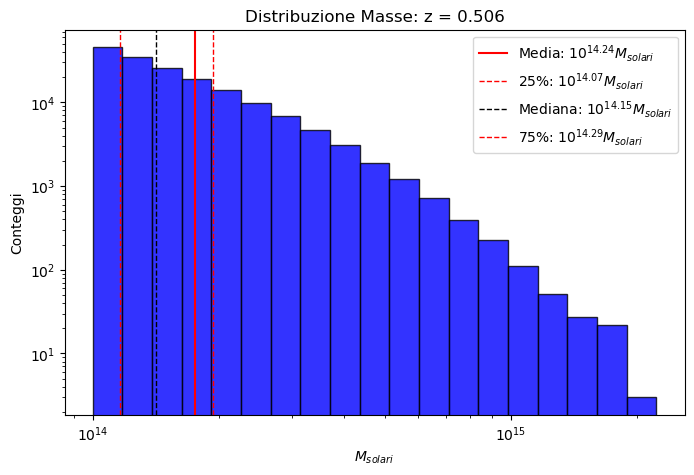

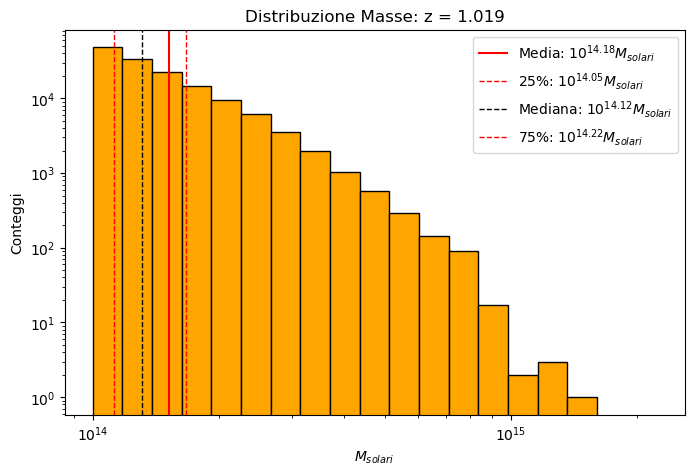

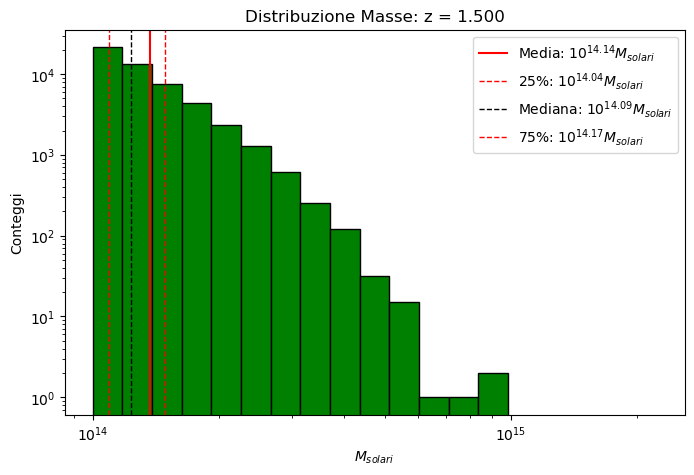

In [135]:
##istogramma per z1
plt.figure(figsize=(8, 5))
plt.hist(z1.mass, bins=bins_log, color='blue',edgecolor='black', linewidth=1, alpha = 0.8)
plt.xscale('log')
plt.yscale('log')
plt.axvline(media1, color='red', linestyle='-', linewidth=1.5, label=rf'Media: $10^{{{np.log10(media1):.2f}}} M_{{solari}}$')
plt.axvline(quart1_25, color='red', linestyle='--', linewidth=1, label=rf'25%: $10^{{{np.log10(quart1_25):.2f}}}M_{{solari}}$')
plt.axvline(mediana1, color='black', linestyle='--', linewidth=1, label=rf'Mediana: $10^{{{np.log10(mediana1):.2f}}}M_{{solari}}$')
plt.axvline(quart1_75, color='red', linestyle='--', linewidth=1, label=rf'75%: $10^{{{np.log10(quart1_75):.2f}}}M_{{solari}}$')
plt.xlabel(r'$M_{solari}$')
plt.ylabel('Conteggi')
plt.title('Distribuzione Masse: z = 0.506')
plt.legend()
plt.show()

##istogramma per z2
plt.figure(figsize=(8, 5))
plt.hist(z2.mass, bins=bins_log, color='orange',edgecolor='black', linewidth=1)
plt.xscale('log')
plt.yscale('log')
plt.axvline(media2, color='red', linestyle='-', linewidth=1.5, label=rf'Media: $10^{{{np.log10(media2):.2f}}} M_{{solari}}$')
plt.axvline(quart2_25, color='red', linestyle='--', linewidth=1, label=rf'25%: $10^{{{np.log10(quart2_25):.2f}}}M_{{solari}}$')
plt.axvline(mediana2, color='black', linestyle='--', linewidth=1, label=rf'Mediana: $10^{{{np.log10(mediana2):.2f}}}M_{{solari}}$')
plt.axvline(quart2_75, color='red', linestyle='--', linewidth=1, label=rf'75%: $10^{{{np.log10(quart2_75):.2f}}}M_{{solari}}$')
plt.xlabel(r'$M_{solari}$')
plt.ylabel('Conteggi')
plt.title('Distribuzione Masse: z = 1.019')
plt.legend()
plt.show()

##istogramma per z3
plt.figure(figsize=(8, 5))
plt.hist(z3.mass, bins=bins_log, color='green',edgecolor='black', linewidth=1)
plt.xscale('log')
plt.yscale('log')
plt.axvline(media3, color='red', linestyle='-', linewidth=1.5, label=rf'Media: $10^{{{np.log10(media3):.2f}}} M_{{solari}}$')
plt.axvline(quart3_25, color='red', linestyle='--', linewidth=1, label=rf'25%: $10^{{{np.log10(quart3_25):.2f}}}M_{{solari}}$')
plt.axvline(mediana3, color='black', linestyle='--', linewidth=1, label=rf'Mediana: $10^{{{np.log10(mediana3):.2f}}}M_{{solari}}$')
plt.axvline(quart3_75, color='red', linestyle='--', linewidth=1, label=rf'75%: $10^{{{np.log10(quart3_75):.2f}}}M_{{solari}}$')
plt.xlabel(r'$M_{solari}$')
plt.ylabel('Conteggi')
plt.title('Distribuzione Masse: z = 1.500')
plt.legend()
plt.show()

Ora la consegna chiede di confrontare i conteggi delle osservazioni con quelli deducibili dalla Halo Mass Function calcolata utilizzando dei parametri forniti dal testo. Quello che è stato fatto consiste nel calcolo dei valori assunti dalla HMF in corrispondenza del centro di ogni bin e la conversione nel valore di conteggi associati attraverso la seguente relazione: $$\text{d}n_{i-teorico} = HMF \cdot V \cdot \text{d}lnM_{i}$$
Successivamente sono presentati i grafici in cui vengono messi in relazione i conteggi relativi alle osservazioni del catalogo con i conteggi predetti dalla HMF con i parametri definiti dal testo 

In [193]:
##numero bin riempiti negli istogrammi
bin_1 = 19
bin_2 = 17
bin_3 = 14
## estrapolo i valori che mi servono per calcolare la HMF dagli istogrammi
n1, bin_edge = np.histogram(z1.mass, bins_log)
n2, bin_edge = np.histogram(z2.mass, bins_log)
n3, bin_edge = np.histogram(z3.mass, bins_log)

## il range del bin su cui calcolo la densità è lo stesso per tutti e tre i redshift
dlog_M = np.log(bin_edge[1:]) - np.log(bin_edge[:-1])

## i tre dataframe hanno tre volumi fissati per valore di redshift
V1 = z1.vol.iloc[0]
V2 = z2.vol.iloc[0]
V3 = z3.vol.iloc[0]

## centro dei bin
cntr = np.sqrt(bin_edge[:-1]*bin_edge[1:])

## importo colossus
from colossus.cosmology import cosmology
from colossus.lss import mass_function

## setto i parametri del mio universo
params = {'flat': True, 'H0': 67.77, 'Om0': 0.31, 'Ob0': 0.049,
'sigma8': 0.81, 'ns': 0.96}
cosmology.addCosmology('myCosmo', params)
cosmology.setCosmology('myCosmo')

## estrapolo le predizioni teoriche delle densità per i tre redshift
HMF1_teor = mass_function.massFunction(cntr, z1.z.iloc[0], mdef='vir', model='despali16', q_out='dndlnM')
HMF2_teor = mass_function.massFunction(cntr, z2.z.iloc[0], mdef='vir', model='despali16', q_out='dndlnM')
HMF3_teor = mass_function.massFunction(cntr, z3.z.iloc[0], mdef='vir', model='despali16', q_out='dndlnM')

## converto i valori assunti dall' HMF nei conteggi teorici 
n1_teor = HMF1_teor * (V1 * dlog_M)
n2_teor = HMF2_teor * (V2 * dlog_M)
n3_teor = HMF3_teor * (V3 * dlog_M)

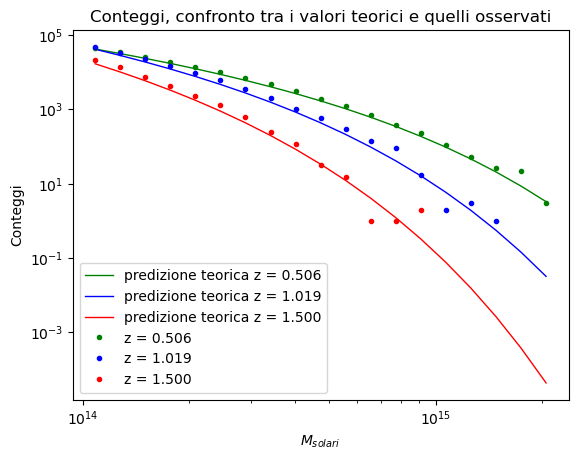

In [137]:
##confronto i valori teorici con quelli osservati
plt.figure()
plt.plot(cntr, n1_teor, label = 'predizione teorica z = 0.506', color = 'green', linewidth = 1)
plt.plot(cntr, n2_teor, label = 'predizione teorica z = 1.019', color = 'blue', linewidth = 1)
plt.plot(cntr, n3_teor, label = 'predizione teorica z = 1.500', color = 'red', linewidth = 1)
plt.plot(cntr, n1, color = 'green', markersize = 3, marker='o', linestyle='none', label = 'z = 0.506')
plt.plot(cntr, n2, color = 'blue', markersize = 3, marker='o', linestyle='none', label = 'z = 1.019')
plt.plot(cntr, n3, color = 'red', markersize = 3, marker='o', linestyle='none', label = 'z = 1.500')
plt.title('Conteggi, confronto tra i valori teorici e quelli osservati')
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$M_{solari}$')
plt.ylabel('Conteggi')
plt.legend()
plt.show()

Dal grafico emerge che il modello approssima abbastanza bene il numero di conteggi osservato in ogni bin di massa per tutti e 3 i bin di redshift, inoltre in questo grafico emerge come il numero di ammassi di galassie nell'universo a masse più grande aumenti con il passare del tempo come ci si aspetta che sia. Al fine di avere un parametro oggettivo per valutare quanto bene il modello approssima le simulazioni è stato calcolato il $\chi^{2}$ diviso per N - k dove N è il numero di bin riempiti degli istogrammi, mentre k è il numero di parametri liberi:

In [194]:
chi_quad1 = np.sum(((n1-n1_teor)**2) / n1_teor) / bin_1
chi_quad2 = np.sum(((n2-n2_teor)**2) / n2_teor) / bin_2
chi_quad3 = np.sum(((n3-n3_teor)**2) / n3_teor) / bin_3
chi_quad_tot = (np.sum(((n1-n1_teor)**2)/n1_teor) + np.sum(((n2-n2_teor)**2)/n2_teor) + np.sum(((n3-n3_teor)**2)/n3_teor)) / (bin_1 + bin_2 + bin_3)

print(rf'z = 0.506, $\chi^{{2}}$ = {chi_quad1:.3f}')
print(rf'z = 1.019, $\chi^{{2}}$ = {chi_quad2:.3f}')                   
print(rf'z = 1.500, $\chi^{{2}}$ = {chi_quad3:.3f}') 
print(f'modello totale, chi_quadro = {chi_quad_tot:.3f}')

z = 0.506, $\chi^{2}$ = 88.795
z = 1.019, $\chi^{2}$ = 255.465
z = 1.500, $\chi^{2}$ = 262.825
modello totale, chi_quadro = 194.191


Ora che è stato confrontato l'andamento teorico previsto dal modello con le osservazioni, si è passato alla fase di inferenza statistica al fine di comprendere il valore dei parametri che meglio descrivono le osservazioni con i modelli utilizzati. La prima parte é stata svolta utilizzando il modello dell'universo piatto, ovvero l'universo in cui vale la seguente relazione: $$\Omega_{de,0} = 1 - \Omega_{m,0}$$
Nella seconda parte invece è stato utilizzato un modello in cui è ipotizzata una possibile curvatura per l'universo e in cui vale la seguente relazione: $$\Omega_{k,0} = 1 - \Omega_{m,0} - \Omega_{de,0}$$ che si riduce alla prima relazione se $\Omega_{k,0} = 0$. Per quanto riguarda il codice il procedimento utilizzato è stato quello basato sul teorema di bayes:$$ P(A|B) = \frac{P(B|A) P(A)}{P(B)} $$ che nel caso presente assume la forma $$P(\theta|D) = \frac{P(D|\theta) P(\theta)}{P(D)}$$
dove $\theta$ sta per i parametri che utilizza il modello e D sta per i dati (osservazioni) che si hanno a disposizione; il concetto fondamentale e utilizzato nel processo di inferenza è che trovando $P(\theta|D)$ si sta trovando la funzione di distribuzione dei parametri del modello in esame, dalla funzione di distribuzione poi si può ottenere la stima migliore dei parametri rispetto al modello e ai dati analizzati. Nel codice è quindi stata campionata la funzione di distribuzione $P(\theta|D)$ detta posterior (in realtà è stata campionata la funzione logaritmo della posterior che però non cambia i concetti riguardanti la stima dei parametri); essendo che il numero di dati a disposizione è grande è stato possibile utilizzare come variabile il numero di conteggi nel singolo bin di massa con funzione di distribuzione poisoniana, la likelihood utilizzata ($P(D|\theta)$) è quindi il prodotto tra tutte le poissoniane relative ad ogni bin (di massa), mentre la prior($P(\theta)$) nel caso universo piatto è stata considerata uniforme nell'intervallo fisicamente accettabile per i parametri, infine $P(D)$ non viene considerata essendo il fattore di normalizzazione; il campionamento della posterior è stato effettuato utilizzando un algoritmo che implementa il metodo MCMC attraverso l'utilizzo di più walkers che mappano lo spazio dei parametri in maniera dipendente l'uno dall'altro in modo da poter evitare che l'esplorazione rimanga arenata in massimi locali della funzione.  

In [139]:
##parte di inferenza bayesiana 
## questa cella impiega molto tempo per essere eseguita, nella prossima importo i samples che ho ottenuto in locale
##definizione della log_prior uguale per tutti e tre i bins di redshift
def log_prior(theta):
    s8, om = theta
    if 0.1 <= om <= 0.99 and 0.1 <= s8 <= 1.1:
        return 0.0
    return -np.inf

##definizione della log_likelyhood utilizzando come parametri di inigresso oltre che sigma8 e om0 anche il dataframe che sto studiando e i conteggi associati
def log_likelyhood(theta, df, n):
    s8, om = theta
    ##setto i parametri del nuovo universo
    params = {'flat': True, 'H0': 67.77, 'Om0': om, 'Ob0': 0.049,
    'sigma8': s8, 'ns': 0.95}
    cosmology.addCosmology('myCosmo', params)
    cosmology.setCosmology('myCosmo')
    
    ##trovo la densità teorica di conteggi e la converto nel numero di conteggi 
    dens_teor = mass_function.massFunction(cntr, df.z.iloc[0], mdef='vir', model='despali16', q_out='dndlnM')
    n_teor = dens_teor * df.vol.iloc[0] * dlog_M
    
    ##limite per evitare di avere -inf
    n_teor = np.maximum(n_teor, 1e-10)
    
    ##scrivo la funzione loglikelyhood (escludendo il termine che non dipende dai parametri)
    ll = np.sum(n * np.log(n_teor) - n_teor)
    return ll

##definisco la log_posterior che sarà poi la funzione chè campionerà emcee
def log_posterior(theta, df, n):
    s8, om = theta
    if not np.isfinite(log_prior(theta)):
        return -np.inf
    return log_prior(theta) + log_likelyhood(theta, df, n)

##====================================================##
##ricerca del punto di partenza migliore per gli walkers
##====================================================##

from scipy.optimize import minimize
rng = np.random.default_rng()

##funzione da minimizzare
def nll(theta, df, n):
    return -log_posterior(theta, df, n)

##parametri che usa minimize()
limiti = ((0.1, 1.1), (0.1, 0.99)) ##limiti imposti anche dalla prior
start = np.array([params['sigma8'], params['Om0']])##punti di partenza di minimize()

##applicazione di minimize() per i tre diversi dataframes
max_ll1 = minimize(nll, start, args=(z1, n1), bounds=limiti)
max_ll2 = minimize(nll, start, args=(z2, n2), bounds=limiti)  
max_ll3 = minimize(nll, start, args=(z3, n3), bounds=limiti)    

##risultato della ricerca del minimo per i 3 dataframes
start_pos1 = max_ll1.x
start_pos2 = max_ll2.x
start_pos3 = max_ll3.x 

##===================##
##applicazione di emcee
##===================##

import emcee

##parametri emcee
nwalkers = 20
ndim = 2
passi = 1000

##posizione di partenza degli walkers nei 3 dataframes
pos_walk1 = start_pos1 + 1e-4 * rng.normal(size=(nwalkers, ndim))
pos_walk2 = start_pos2 + 1e-4 * rng.normal(size=(nwalkers, ndim))
pos_walk3 = start_pos3 + 1e-4 * rng.normal(size=(nwalkers, ndim))

##applicazione algoritmo
sampler1 = emcee.EnsembleSampler(nwalkers, ndim, log_posterior, args=(z1, n1))
sampler1.run_mcmc(pos_walk1, passi, progress=True); 

sampler2 = emcee.EnsembleSampler(nwalkers, ndim, log_posterior, args=(z2, n2))
sampler2.run_mcmc(pos_walk2, passi, progress=True);  

sampler3 = emcee.EnsembleSampler(nwalkers, ndim, log_posterior, args=(z3, n3))
sampler3.run_mcmc(pos_walk3, passi, progress=True);

##assegno alle variabili samples gli array contenenti i campioni eliminando i primi 150 passi degli walkers    
samples1 = sampler1.get_chain()[150:,:,:]
samples2 = sampler2.get_chain()[150:,:,:]
samples3 = sampler3.get_chain()[150:,:,:]

##sistemo la matrice del campione in maniera tale da avere solo 2 colonne con i valori dei 2 parametri
flat_samples1 = samples1.reshape(-1,2)
flat_samples2 = samples2.reshape(-1,2)
flat_samples3 = samples3.reshape(-1,2)

100%|██████████| 1000/1000 [56:38<00:00,  3.40s/it]


In [140]:
##salvo np.array i samples già ottenuti in locale
#fstart1 = np.loadtxt("parametri_z1.csv", delimiter=",", skiprows=1)
#flat_samples1 = fstart1[150*20:,] 

#fstart2 = np.loadtxt("parametri_z2.csv", delimiter=",", skiprows=1)
#flat_samples2 = fstart2[150*20:,]

#fstart3 = np.loadtxt("parametri_z3.csv", delimiter=",", skiprows=1)
#flat_samples3 = fstart3[150*20:,]

Ora prima di visualizzare le funzioni di distribuzione dei parametri viene mostrato come esempio il grafico relativo alla sequenza di posizioni nello spazio dei parametri accettate degli walkers in maniera da giustificare la scelta di eliminare le prime 150 posizioni:

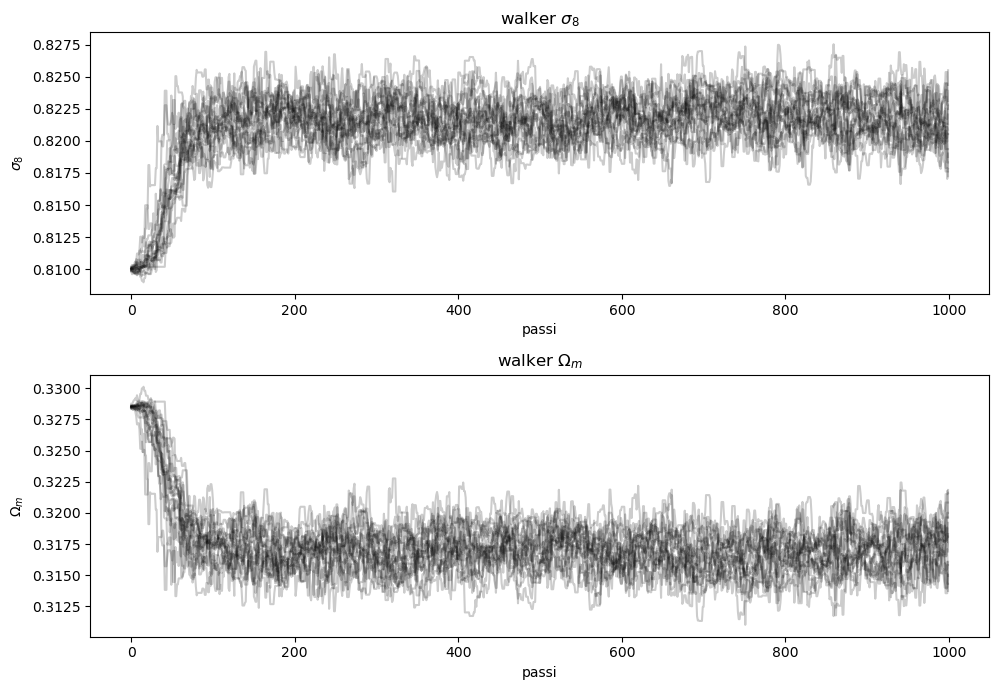

In [141]:
##array con tutti le posizioni accettate dei 20 walkers
#passi = 1000 ##da commentare nel caso si volesse rifare il campionamento
#nwalkers = 20 ##da commentare nel caso si volesse rifare il campionamento

#sample_walk = fstart1.reshape(-1,20,2) ##da commentare nel caso si volesse rifare il campionamento
sample_walk = sampler1.get_chain() # da decommentare nel caso si volesse rifare il campionamento

fig = plt.figure(figsize=(10, 7))

##proiezione posizione su sigma8
ax1 = fig.add_subplot(211)
for i in range(nwalkers):
    ax1.plot(np.arange(passi),sample_walk[:,i,0], color = 'black', alpha = 0.2)
ax1.set_title(r'walker $\sigma_{8}$')
ax1.set_xlabel('passi')
ax1.set_ylabel(r'$\sigma_{8}$')

##proiezione posizione su om0
ax2 = fig.add_subplot(212)
for i in range(nwalkers):
    ax2.plot(np.arange(passi),sample_walk[:,i,1], color = 'black', alpha = 0.2)
ax2.set_title(r'walker $\Omega_m$')
ax2.set_xlabel('passi')
ax2.set_ylabel(r'$\Omega_m$')
plt.tight_layout()
plt.show()

Nelle prossime celle viene gestita la visualizzazione del campione delle funzioni di distribuzione marginale di $\Omega_{m,0}$ e di $\sigma_{8}$ attraverso due istogrammi per ogni bin di redshift:

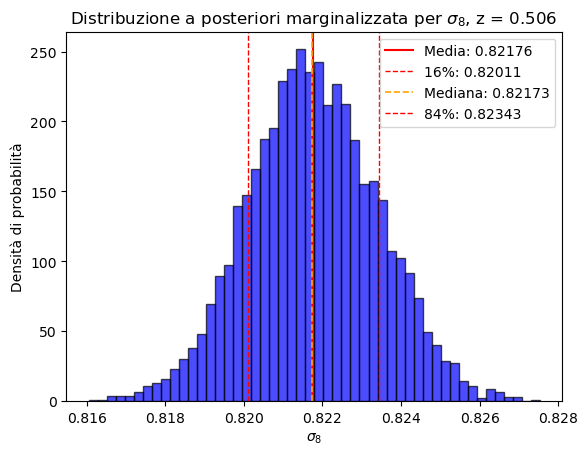

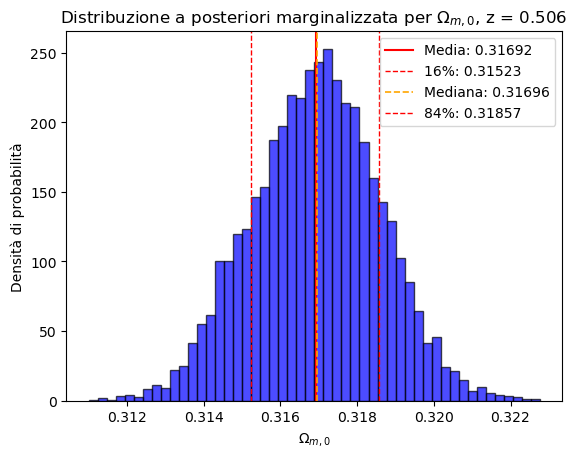

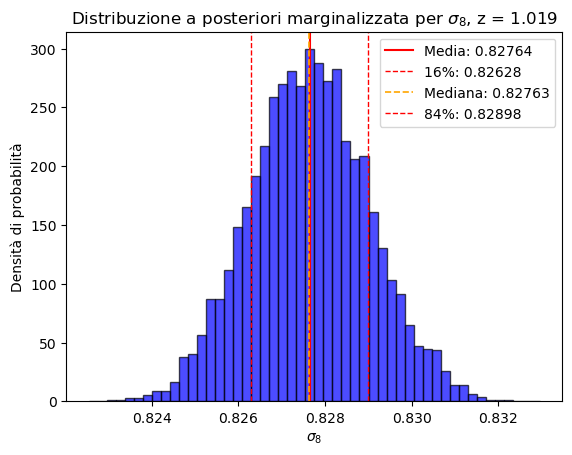

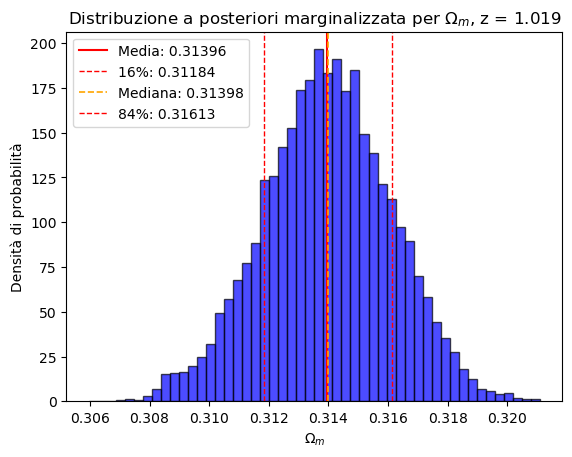

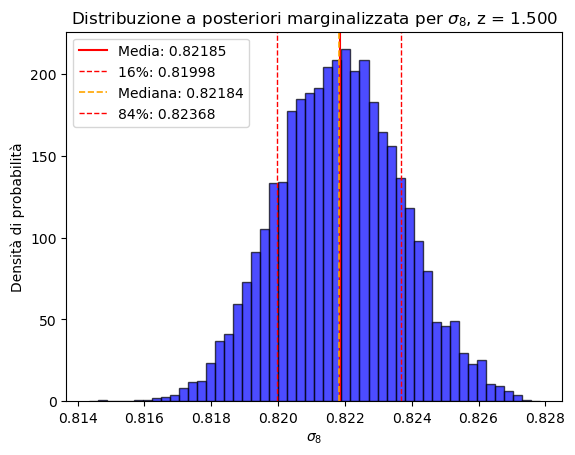

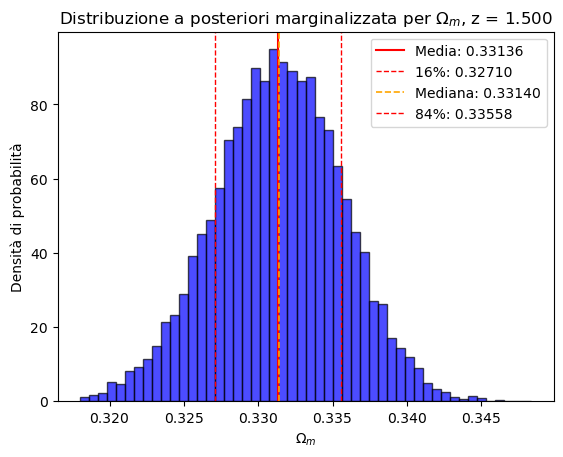

In [142]:
# dai conteggi degli istogrammi estrapolo la media e la mediana che posso utilizzare come stimatori del parametro
# e la varianza intesa come l'intervallo che contiene il 68% dei valori possibili del parametro
s8_1_mean = np.mean(flat_samples1[:, 0])
s8_1_16 = np.percentile(flat_samples1[:, 0], 16)
s8_1_median = np.percentile(flat_samples1[:, 0], 50)
s8_1_84 = np.percentile(flat_samples1[:, 0], 84)

om0_1_mean = np.mean(flat_samples1[:, 1])
om0_1_16 = np.percentile(flat_samples1[:, 1], 16)
om0_1_median = np.percentile(flat_samples1[:, 1], 50)
om0_1_84 = np.percentile(flat_samples1[:, 1], 84)

# Calcoli per z2
s8_2_mean = np.mean(flat_samples2[:, 0])
s8_2_16 = np.percentile(flat_samples2[:, 0], 16)
s8_2_median = np.percentile(flat_samples2[:, 0], 50)
s8_2_84 = np.percentile(flat_samples2[:, 0], 84)

om0_2_mean = np.mean(flat_samples2[:, 1])
om0_2_16 = np.percentile(flat_samples2[:, 1], 16)
om0_2_median = np.percentile(flat_samples2[:, 1], 50)
om0_2_84 = np.percentile(flat_samples2[:, 1], 84)

# Calcoli per z3
s8_3_mean = np.mean(flat_samples3[:, 0])
s8_3_16 = np.percentile(flat_samples3[:, 0], 16)
s8_3_median = np.percentile(flat_samples3[:, 0], 50)
s8_3_84 = np.percentile(flat_samples3[:, 0], 84)

om0_3_mean = np.mean(flat_samples3[:, 1])
om0_3_16 = np.percentile(flat_samples3[:, 1], 16)
om0_3_median = np.percentile(flat_samples3[:, 1], 50)
om0_3_84 = np.percentile(flat_samples3[:, 1], 84)


##marginalizzate z1
plt.figure()
plt.hist(flat_samples1[:, 0], bins=50, density=True, color='blue', alpha=0.7, edgecolor='black')
plt.axvline(s8_1_mean, color='red', linestyle='-', linewidth=1.5, label=f'Media: {s8_1_mean:.5f}')
plt.axvline(s8_1_16, color='red', linestyle='--', linewidth=1, label=f'16%: {s8_1_16:.5f}')
plt.axvline(s8_1_median, color='orange', linestyle='--', linewidth=1.2, label=f'Mediana: {s8_1_median:.5f}')
plt.axvline(s8_1_84, color='red', linestyle='--', linewidth=1, label=f'84%: {s8_1_84:.5f}')
plt.title(r'Distribuzione a posteriori marginalizzata per $\sigma_{8}$, z = 0.506 ')
plt.xlabel(r'$\sigma_{8}$')
plt.ylabel('Densità di probabilità')
plt.legend()
plt.show() 

plt.figure()
plt.hist(flat_samples1[:, 1], bins=50, density=True, color='blue', alpha=0.7, edgecolor='black')
plt.axvline(om0_1_mean, color='red', linestyle='-', linewidth=1.5, label=f'Media: {om0_1_mean:.5f}')
plt.axvline(om0_1_16, color='red', linestyle='--', linewidth=1, label=f'16%: {om0_1_16:.5f}')
plt.axvline(om0_1_median, color='orange', linestyle='--', linewidth=1.2, label=f'Mediana: {om0_1_median:.5f}')
plt.axvline(om0_1_84, color='red', linestyle='--', linewidth=1, label=f'84%: {om0_1_84:.5f}')
plt.title(r'Distribuzione a posteriori marginalizzata per $\Omega_{m,0}$, z = 0.506 ')
plt.xlabel(r'$\Omega_{m,0}$')
plt.ylabel('Densità di probabilità')
plt.legend()
plt.show()     
 
##marginalizzate z2
plt.figure()
plt.hist(flat_samples2[:, 0], bins=50, density=True, color='blue', alpha=0.7, edgecolor='black')
plt.axvline(s8_2_mean, color='red', linestyle='-', linewidth=1.5, label=f'Media: {s8_2_mean:.5f}')
plt.axvline(s8_2_16, color='red', linestyle='--', linewidth=1, label=f'16%: {s8_2_16:.5f}')
plt.axvline(s8_2_median, color='orange', linestyle='--', linewidth=1.2, label=f'Mediana: {s8_2_median:.5f}')
plt.axvline(s8_2_84, color='red', linestyle='--', linewidth=1, label=f'84%: {s8_2_84:.5f}')
plt.title(r'Distribuzione a posteriori marginalizzata per $\sigma_8$, z = 1.019')
plt.xlabel(r'$\sigma_8$')
plt.ylabel('Densità di probabilità')
plt.legend()
plt.show() 

plt.figure()
plt.hist(flat_samples2[:, 1], bins=50, density=True, color='blue', alpha=0.7, edgecolor='black')
plt.axvline(om0_2_mean, color='red', linestyle='-', linewidth=1.5, label=f'Media: {om0_2_mean:.5f}')
plt.axvline(om0_2_16, color='red', linestyle='--', linewidth=1, label=f'16%: {om0_2_16:.5f}')
plt.axvline(om0_2_median, color='orange', linestyle='--', linewidth=1.2, label=f'Mediana: {om0_2_median:.5f}')
plt.axvline(om0_2_84, color='red', linestyle='--', linewidth=1, label=f'84%: {om0_2_84:.5f}')
plt.title(r'Distribuzione a posteriori marginalizzata per $\Omega_m$, z = 1.019')
plt.xlabel(r'$\Omega_m$')
plt.ylabel('Densità di probabilità')
plt.legend()
plt.show()        
    
##marginalizzate z3
plt.figure()
plt.hist(flat_samples3[:, 0], bins=50, density=True, color='blue', alpha=0.7, edgecolor='black')
plt.axvline(s8_3_mean, color='red', linestyle='-', linewidth=1.5, label=f'Media: {s8_3_mean:.5f}')
plt.axvline(s8_3_16, color='red', linestyle='--', linewidth=1, label=f'16%: {s8_3_16:.5f}')
plt.axvline(s8_3_median, color='orange', linestyle='--', linewidth=1.2, label=f'Mediana: {s8_3_median:.5f}')
plt.axvline(s8_3_84, color='red', linestyle='--', linewidth=1, label=f'84%: {s8_3_84:.5f}')
plt.title(r'Distribuzione a posteriori marginalizzata per $\sigma_8$, z = 1.500')
plt.xlabel(r'$\sigma_8$')
plt.ylabel('Densità di probabilità')
plt.legend()
plt.show() 

plt.figure()
plt.hist(flat_samples3[:, 1], bins=50, density=True, color='blue', alpha=0.7, edgecolor='black')
plt.axvline(om0_3_mean, color='red', linestyle='-', linewidth=1.5, label=f'Media: {om0_3_mean:.5f}')
plt.axvline(om0_3_16, color='red', linestyle='--', linewidth=1, label=f'16%: {om0_3_16:.5f}')
plt.axvline(om0_3_median, color='orange', linestyle='--', linewidth=1.2, label=f'Mediana: {om0_3_median:.5f}')
plt.axvline(om0_3_84, color='red', linestyle='--', linewidth=1, label=f'84%: {om0_3_84:.5f}')
plt.title(r'Distribuzione a posteriori marginalizzata per $\Omega_m$, z = 1.500')
plt.xlabel(r'$\Omega_m$')
plt.ylabel('Densità di probabilità')
plt.legend()
plt.show()

Di seguito la visualizzazione del confronto tra i valori assunti dalla HMF con i parametri stimati nei tre casi rispetto ai conteggi:

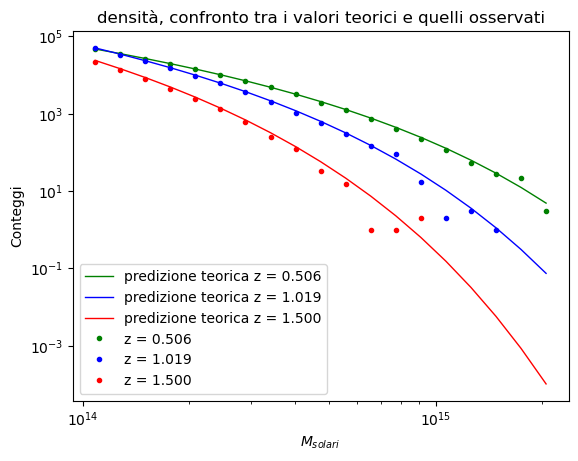

In [191]:
##confronto i valori teorici con quelli osservati

## setto i parametri dell'universo con cui calcolo n_1 teorico di z1

params = {'flat': True, 'H0': 67.77, 'Om0': om0_1_mean, 'Ob0': 0.049,
'sigma8': s8_1_mean, 'ns': 0.96}
cosmology.addCosmology('myCosmo', params)
cosmology.setCosmology('myCosmo')

## calcolo la HMF nei centri di ogni bin di massa con i nuovi parametri
HMF1_teor = mass_function.massFunction(cntr, z1.z.iloc[0], mdef='vir', model='despali16', q_out='dndlnM')

## converto in conteggi
n1_teor = HMF1_teor * (V1 * dlog_M)

## setto i parametri dell'universo con cui calcolo n_2 teorico di z2

params = {'flat': True, 'H0': 67.77, 'Om0': om0_2_mean, 'Ob0': 0.049,
'sigma8': s8_2_mean, 'ns': 0.96}
cosmology.addCosmology('myCosmo', params)
cosmology.setCosmology('myCosmo')

## calcolo la HMF nei centri di ogni bin di massa con i nuovi parametri
HMF2_teor = mass_function.massFunction(cntr, z2.z.iloc[0], mdef='vir', model='despali16', q_out='dndlnM')

## converto in conteggi
n2_teor = HMF2_teor * (V2 * dlog_M)

## setto i parametri dell'universo con cui calcolo n_3 teorico di z3

params = {'flat': True, 'H0': 67.77, 'Om0': om0_3_mean, 'Ob0': 0.049,
'sigma8': s8_3_mean, 'ns': 0.96}
cosmology.addCosmology('myCosmo', params)
cosmology.setCosmology('myCosmo')

## calcolo la HMF nei centri di ogni bin di massa con i nuovi parametri
HMF3_teor = mass_function.massFunction(cntr, z3.z.iloc[0], mdef='vir', model='despali16', q_out='dndlnM')

## converto in conteggi
n3_teor = HMF3_teor * (V3 * dlog_M)

## plotto i grafici del confronto
plt.figure()
plt.plot(cntr, n1_teor, label = 'predizione teorica z = 0.506', color = 'green', linewidth = 1)
plt.plot(cntr, n2_teor, label = 'predizione teorica z = 1.019', color = 'blue', linewidth = 1)
plt.plot(cntr, n3_teor, label = 'predizione teorica z = 1.500', color = 'red', linewidth = 1)
plt.plot(cntr, n1, color = 'green', markersize = 3, marker='o', linestyle='none', label = 'z = 0.506')
plt.plot(cntr, n2, color = 'blue', markersize = 3, marker='o', linestyle='none', label = 'z = 1.019')
plt.plot(cntr, n3, color = 'red', markersize = 3, marker='o', linestyle='none', label = 'z = 1.500')
plt.title('densità, confronto tra i valori teorici e quelli osservati')
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$M_{solari}$')
plt.ylabel('Conteggi')
plt.legend()
plt.show()

Al fine di avere un parametro oggettivo per valutare quanto bene il modello approssima le simulazioni è stato calcolato il $\chi^{2}$ ridotto (per poter confrontare modelli con gradi di libertà diversi):

In [192]:
chi_quad1 = np.sum(((n1-n1_teor)**2) / n1_teor) / (bin_1 - 2)
chi_quad2 = np.sum(((n2-n2_teor)**2) / n2_teor) / (bin_2 - 2)
chi_quad3 = np.sum(((n3-n3_teor)**2) / n3_teor) / (bin_3 - 2)
chi_quad_tot = (np.sum(((n1-n1_teor)**2)/n1_teor) + np.sum(((n2-n2_teor)**2)/n2_teor) + np.sum(((n3-n3_teor)**2)/n3_teor)) / (bin_1 + bin_2 + bin_3 - 6)

print(f'z = 0.506, chi_quadro = {chi_quad1:.3f}')
print(f'z = 1.019, chi_quadro = {chi_quad2:.3f}')                   
print(f'z = 1.500, chi_quadro = {chi_quad3:.3f}')
print(f'modello totale, chi_quadro = {chi_quad_tot:.3f}') 

z = 0.506, chi_quadro = 4.411
z = 1.019, chi_quadro = 11.529
z = 1.500, chi_quadro = 36.972
modello totale, chi_quadro = 15.718


si nota quindi una grande diminuzione nei valori del $\chi^{2}$ rispetto a quando è stato calcolato nel confronto con i parametri preimpostati, il che è segno del fatto che i nuovi modelli approssimano meglio i dati a disposizione.

Di seguito invece le proiezioni in 2D della distribuzione bidimensionale dei parametri per i tre bin di redshift dai quale emerge la forte anticorrelazione tra i due parametri

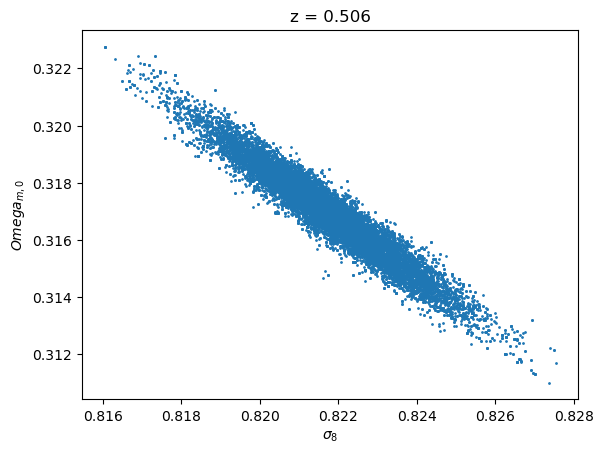

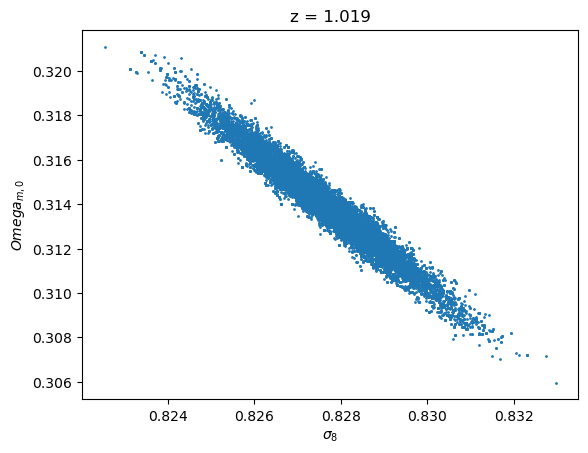

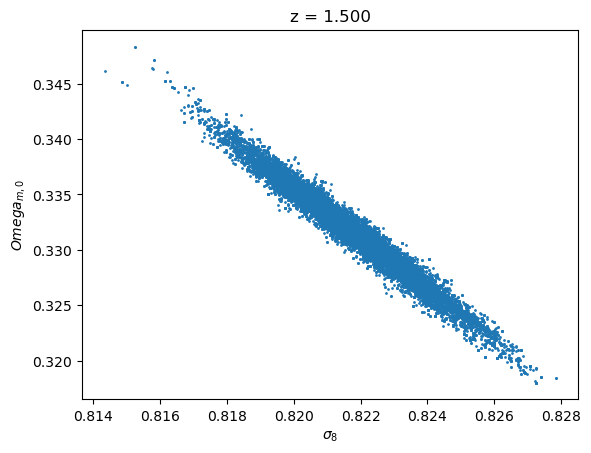

In [145]:
##correlazione z1
plt.figure()
plt.scatter(flat_samples1[:, 0], flat_samples1[:, 1], s = 1)
plt.xlabel(r'$\sigma_{8}$')
plt.ylabel(r'$Omega_{m,0}$')
plt.title('z = 0.506')
plt.show()

##correlazione z2
plt.figure()
plt.scatter(flat_samples2[:, 0], flat_samples2[:, 1], s = 1)
plt.xlabel(r'$\sigma_{8}$')
plt.ylabel(r'$Omega_{m,0}$')
plt.title('z = 1.019')
plt.show()

##correlazione z3
plt.figure()
plt.scatter(flat_samples3[:, 0], flat_samples3[:, 1], s = 1)
plt.xlabel(r'$\sigma_{8}$')
plt.ylabel(r'$Omega_{m,0}$')
plt.title('z = 1.500')
plt.show()

Di seguito la visualizzazione completa della distribuzione tramite la libreria pygtc dove sono presenti  anche le linee di isodensità:

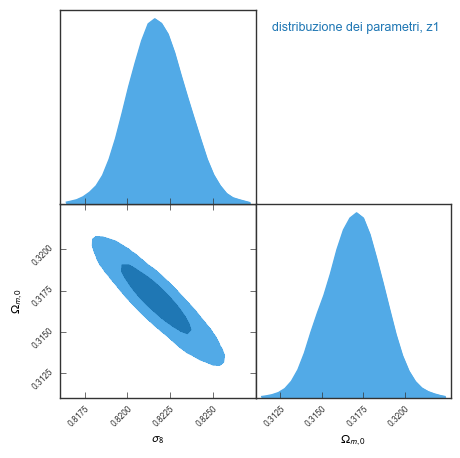

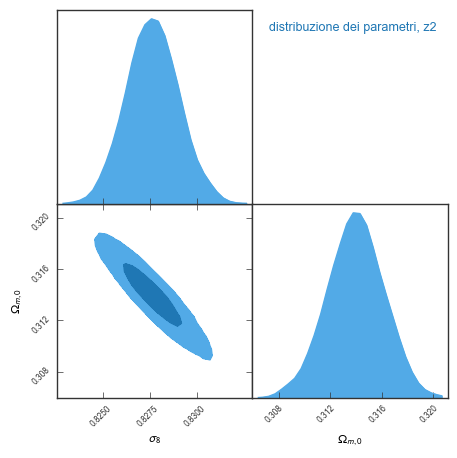

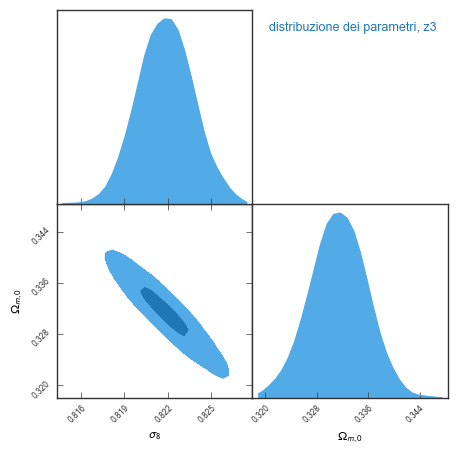

In [146]:
import pygtc

## z1
GTC = pygtc.plotGTC(chains=flat_samples1,
                    paramNames=[r'$\sigma_{8}$','$\Omega_{m,0}$'],
                    chainLabels=['distribuzione dei parametri, z1'],
                    figureSize='MNRAS_page')

## z2
GTC = pygtc.plotGTC(chains=flat_samples2,
                    paramNames=[r'$\sigma_{8}$','$\Omega_{m,0}$'],
                    chainLabels=['distribuzione dei parametri, z2'],
                    figureSize='MNRAS_page')

## z3
GTC = pygtc.plotGTC(chains=flat_samples3,
                    paramNames=[r'$\sigma_{8}$','$\Omega_{m,0}$'],
                    chainLabels=['distribuzione dei parametri, z3'],
                    figureSize='MNRAS_page')

da questi grafici emerge come la funzione di distribuzione congiunta dei due parametri tenda ad una binormale con una forte anticorrelazione

Di seguito viene ripetuta la stessa analisi ma utilizzando, per la stima dei parametri, i conteggi per bin di massa di tutti e 3 i bin di redshift. La scelta è giustificata dal fatto che i parametri da stimare sono gli stessi per i tre bin di redshift e quindi in realtà non ha senso usare 3 coppie di parametri diversi, perchè è in realtà come assumere che i dati siano stati raccolti in 3 universi diversi. L'unica sostanziale differenza rispetto all'analisi fatta precedentemente risiede nella forma della log_likelyhood che ora è la somma delle tre log_likelyhood di prima (ipotizzando che i conteggi nei tre istogrammi siano indipendenti):

In [147]:
##setto i parametri del mio universo
params = {'flat': True, 'H0': 67.77, 'Om0': 0.31, 'Ob0': 0.049, 'sigma8': 0.81, 'ns': 0.96}
cosmology.addCosmology('myCosmo', params)
cosmology.setCosmology('myCosmo')

##analisi congiunta
def log_prior(theta):
    s8, om = theta
    if 0.1 <= om <= 0.99 and 0.1 <= s8 <= 1.1:
        return 0.0
    return -np.inf

def log_likelyhood_tot(theta):
    s8, om = theta
    ##setto del nuovo universo
    params = {'flat': True, 'H0': 67.77, 'Om0': om, 'Ob0': 0.049,
    'sigma8': s8, 'ns': 0.95}
    cosmology.addCosmology('myCosmo', params)
    cosmology.setCosmology('myCosmo')
    
    ##trovo la densità teorica di conteggi e la converto nel numero di conteggi
    dens_teor1 = mass_function.massFunction(cntr, z1.z.iloc[0], mdef='vir', model='despali16', q_out='dndlnM')
    n_teor1 = dens_teor1 * z1.vol.iloc[0] * dlog_M
    
    dens_teor2 = mass_function.massFunction(cntr, z2.z.iloc[0], mdef='vir', model='despali16', q_out='dndlnM')
    n_teor2 = dens_teor2 * z2.vol.iloc[0] * dlog_M
    
    dens_teor3 = mass_function.massFunction(cntr, z3.z.iloc[0], mdef='vir', model='despali16', q_out='dndlnM')
    n_teor3 = dens_teor3 * z3.vol.iloc[0] * dlog_M
    
    ##limite per evitare di avere -inf
    n_teor1 = np.maximum(n_teor1, 1e-10)
    n_teor2 = np.maximum(n_teor2, 1e-10)
    n_teor3 = np.maximum(n_teor3, 1e-10)
    
    ##scrivo la funzione loglikelyhood (escludendo il termine che non dipende dai parametri)
    ll1 = np.sum(n1 * np.log(n_teor1) - n_teor1) 
    ll2 = np.sum(n2 * np.log(n_teor2) - n_teor2) 
    ll3 = np.sum(n3 * np.log(n_teor3) - n_teor3) 
    return ll1 + ll2 + ll3
    
def log_posterior_tot(theta):
    s8, om = theta
    if not np.isfinite(log_prior(theta)):
        return -np.inf
    return log_prior(theta) + log_likelyhood_tot(theta)

##inizio la parte di inferenza vera e propria
import emcee
from scipy.optimize import minimize
rng = np.random.default_rng()

##funzione da minimizzare
def nll_tot(theta):
    return -log_posterior_tot(theta)

##parametri che usa minimize
limiti = ((0.1, 1.1), (0.1, 0.99))
start = np.array([params['sigma8'], params['Om0']]) 

##applicazione di minimize
max_ll_tot = minimize(nll_tot, start, bounds=limiti)
start_pos_tot = max_ll_tot.x

##parametri emcee
nwalkers = 20
ndim = 2
passi = 1000

pos_walk_tot = start_pos_tot + 1e-4 * rng.normal(size=(nwalkers, ndim))

##applicazione algoritmo
sampler_tot = emcee.EnsembleSampler(nwalkers, ndim, log_posterior_tot)
sampler_tot.run_mcmc(pos_walk_tot, passi, progress=True);

## creazione del campione
samples_tot = sampler_tot.get_chain()[150:,:,:]
flat_samples_tot = samples_tot.reshape(-1,2)

100%|██████████| 1000/1000 [55:13<00:00,  3.31s/it]


In [148]:
##salvo in np.array i samples già ottenuti in locale
#fstart_tot = np.loadtxt("parametri_tot.csv", delimiter=",", skiprows=1)
#flat_samples_tot = fstart_tot[20*150:,]

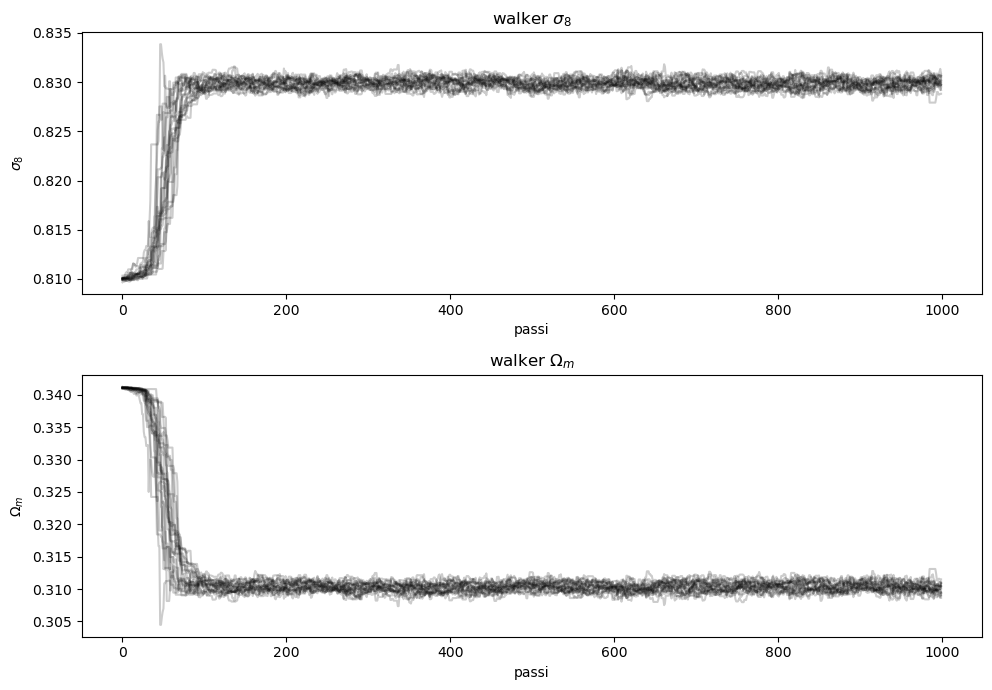

In [149]:
#======================#
##controllo fase burn-in
#======================#

##array con tutti le posizioni accettate dei 20 walkers
sample_walk_tot = sampler_tot.get_chain() ## decommentare se si vuole fare il campionamento
#sample_walk_tot = fstart_tot.reshape(-1,20,2) ## commentare se si vuole rifare il campionamento
fig = plt.figure(figsize=(10, 7))

##proiezione posizione su sigma8
ax1 = fig.add_subplot(211)
for i in range(nwalkers):
    ax1.plot(np.arange(passi),sample_walk_tot[:,i,0], color = 'black', alpha = 0.2)
ax1.set_title(r'walker $\sigma_{8}$')
ax1.set_xlabel('passi')
ax1.set_ylabel(r'$\sigma_{8}$')

##proiezione posizione su om0
ax2 = fig.add_subplot(212)
for i in range(nwalkers):
    ax2.plot(np.arange(passi),sample_walk_tot[:,i,1], color = 'black', alpha = 0.2)
ax2.set_title(r'walker $\Omega_m$')
ax2.set_xlabel('passi')
ax2.set_ylabel(r'$\Omega_m$')
plt.tight_layout()
plt.show()

#========================#
## fine controllo  burn-in
#========================# 

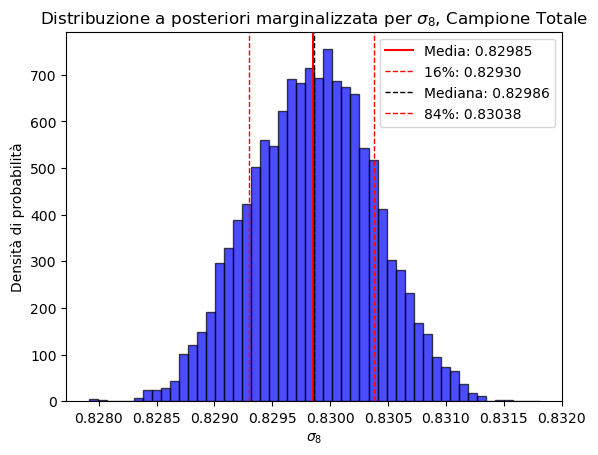

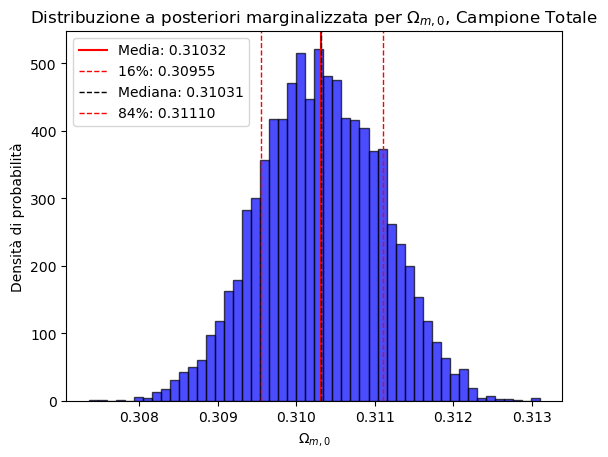

In [150]:
# dai conteggi degli istogrammi estrapolo la media e la mediana che posso utilizzare come stimatori del parametro
# e la varianza intesa come l'intervallo che contiene il 68% dei valori possibili del parametro

s8_tot_mean = np.mean(flat_samples_tot[:, 0])
s8_tot_16 = np.percentile(flat_samples_tot[:, 0], 16)
s8_tot_median = np.percentile(flat_samples_tot[:, 0], 50)
s8_tot_84 = np.percentile(flat_samples_tot[:, 0], 84)

om0_tot_mean = np.mean(flat_samples_tot[:, 1])
om0_tot_16 = np.percentile(flat_samples_tot[:, 1], 16)
om0_tot_median = np.percentile(flat_samples_tot[:, 1], 50)
om0_tot_84 = np.percentile(flat_samples_tot[:, 1], 84)

##marginalizzate
plt.figure()
plt.hist(flat_samples_tot[:, 0], bins=50, density=True, color='blue', alpha=0.7, edgecolor='black')
plt.axvline(s8_tot_mean, color='red', linestyle='-', linewidth=1.5, label=f'Media: {s8_tot_mean:.5f}')
plt.axvline(s8_tot_16, color='red', linestyle='--', linewidth=1, label=f'16%: {s8_tot_16:.5f}')
plt.axvline(s8_tot_median, color='black', linestyle='--', linewidth=1, label=f'Mediana: {s8_tot_median:.5f}')
plt.axvline(s8_tot_84, color='red', linestyle='--', linewidth=1, label=f'84%: {s8_tot_84:.5f}')
plt.title(r'Distribuzione a posteriori marginalizzata per $\sigma_{8}$, Campione Totale')
plt.xlabel(r'$\sigma_{8}$')
plt.ylabel('Densità di probabilità')
plt.legend()
plt.show() 

plt.figure()
plt.hist(flat_samples_tot[:, 1], bins=50, density=True, color='blue', alpha=0.7, edgecolor='black')
plt.axvline(om0_tot_mean, color='red', linestyle='-', linewidth=1.5, label=f'Media: {om0_tot_mean:.5f}')
plt.axvline(om0_tot_16, color='red', linestyle='--', linewidth=1, label=f'16%: {om0_tot_16:.5f}')
plt.axvline(om0_tot_median, color='black', linestyle='--', linewidth=1, label=f'Mediana: {om0_tot_median:.5f}')
plt.axvline(om0_tot_84, color='red', linestyle='--', linewidth=1, label=f'84%: {om0_tot_84:.5f}')
plt.title(r'Distribuzione a posteriori marginalizzata per $\Omega_{m,0}$, Campione Totale')
plt.xlabel(r'$\Omega_{m,0}$')
plt.ylabel('Densità di probabilità')
plt.legend()
plt.show()  

di seguito la visualizzazione del confronto tra i valori assunti dalla HMF con i parametri stimati rispetto ai conteggi

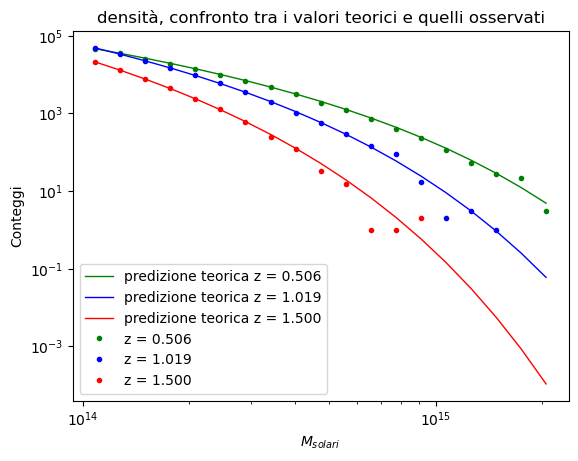

In [189]:
##confronto i valori teorici con quelli osservati

## setto i parametri dell'universo con quelli stimati

params = {'flat': True, 'H0': 67.77, 'Om0': om0_1_mean, 'Ob0': 0.049,
'sigma8': s8_1_mean, 'ns': 0.96}
cosmology.addCosmology('myCosmo', params)
cosmology.setCosmology('myCosmo')

## calcolo la HMF nei centri di ogni bin di massa con i nuovi parametri
HMF1_teor = mass_function.massFunction(cntr, z1.z.iloc[0], mdef='vir', model='despali16', q_out='dndlnM')

## converto in conteggi
n1_teor = HMF1_teor * (V1 * dlog_M)

## calcolo la HMF nei centri di ogni bin di massa con i nuovi parametri
HMF2_teor = mass_function.massFunction(cntr, z2.z.iloc[0], mdef='vir', model='despali16', q_out='dndlnM')

## converto in conteggi
n2_teor = HMF2_teor * (V2 * dlog_M)

## calcolo la HMF nei centri di ogni bin di massa con i nuovi parametri
HMF3_teor = mass_function.massFunction(cntr, z3.z.iloc[0], mdef='vir', model='despali16', q_out='dndlnM')

## converto in conteggi
n3_teor = HMF3_teor * (V3 * dlog_M)

## plotto i grafici del confronto
plt.figure()
plt.plot(cntr, n1_teor, label = 'predizione teorica z = 0.506', color = 'green', linewidth = 1)
plt.plot(cntr, n2_teor, label = 'predizione teorica z = 1.019', color = 'blue', linewidth = 1)
plt.plot(cntr, n3_teor, label = 'predizione teorica z = 1.500', color = 'red', linewidth = 1)
plt.plot(cntr, n1, color = 'green', markersize = 3, marker='o', linestyle='none', label = 'z = 0.506')
plt.plot(cntr, n2, color = 'blue', markersize = 3, marker='o', linestyle='none', label = 'z = 1.019')
plt.plot(cntr, n3, color = 'red', markersize = 3, marker='o', linestyle='none', label = 'z = 1.500')
plt.title('densità, confronto tra i valori teorici e quelli osservati')
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$M_{solari}$')
plt.ylabel('Conteggi')
plt.legend()
plt.show()

Viene calcolato il $\chi^{2}$:

In [190]:
chi_quad_tot = (np.sum(((n1-n1_teor)**2)/n1_teor) + np.sum(((n2-n2_teor)**2)/n2_teor) + np.sum(((n3-n3_teor)**2)/n3_teor)) / (bin_1 + bin_2 + bin_3 - 2)
 
print(f'modello totale, chi_quadro = {chi_quad_tot:.3f}') 

modello totale, chi_quadro = 3.509


Il fatto che il valore del $\chi^{2}$ ridotto sia minore nel caso dell'analisi congiunta rispetto al caso dell'analisi separata è indice del fatto che il modello con i parametri stimati utilizzando tutte le le misure come unico campione sia migliore.

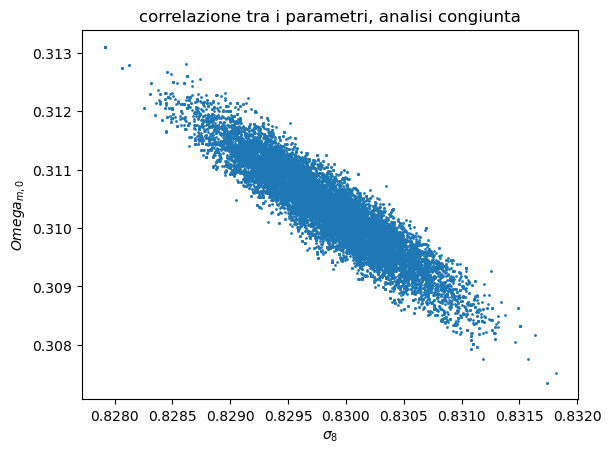

In [153]:
##correlazione dei parametri nel caso dell'analisi congiunta
plt.figure()
plt.scatter(flat_samples_tot[:, 0], flat_samples_tot[:, 1], s = 1)
plt.xlabel(r'$\sigma_{8}$')
plt.ylabel(r'$Omega_{m,0}$')
plt.title('correlazione tra i parametri, analisi congiunta')
plt.show()

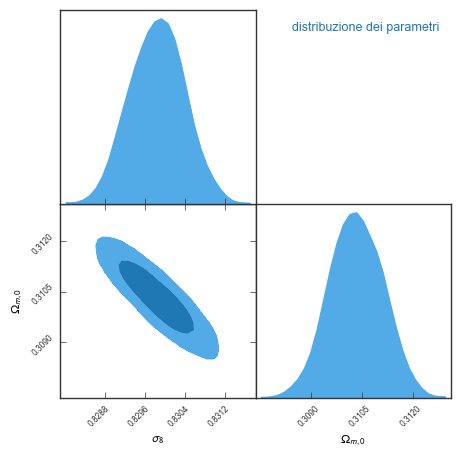

In [154]:
GTC = pygtc.plotGTC(chains=flat_samples_tot,
                    paramNames=[r'$\sigma_{8}$','$\Omega_{m,0}$'],
                    chainLabels=['distribuzione dei parametri'],
                    figureSize='MNRAS_page')

Di seguito invece è presente la stessa analisi sui parametri però considerando il modello dell'universo curvo, quindi come suggerito nel testo oltre che considerare come variabili $\sigma_{8}$ e $\Omega_{m,0}$ adesso verrà considerata come variabile anche il parametro $\Omega_{de,0}$ associato alla densità di energia oscura. Quindi oltre che ripetere la stessa procedura utilizzata precedentemente per trovare la funzione di distribuzione congiunta dei 3 parametri, verranno anche presentati degli istogrammi relativi alla distribuzione di $\Omega_{k}$ che come detto precedentemente definisce la curvatura dell'universo ed è definito come: $$\Omega_{k,0} = 1 - \Omega_{m,0} - \Omega_{de,0}$$ Un'altra differenza rispetto all'analisi precedente risiede nel cambiamento di forma della prior, infatti a differenza di prima nel programma è stato considerato il fatto che $\Omega_{de,0}$ è una variabile con funzione di distribuzione gaussiana con valore atteso e varianza noti da precedenti osservazioni.

In [156]:
def log_prior3(theta):
    s8, om, ode0 = theta
    if 0.1 <= s8 <= 1.1 and 0.05 <= om <= 1.1 and 0.0 <= ode0 <= 1.5: 
        return -0.5 * ((ode0 - 0.7) / 0.05)**2
    return -np.inf

def log_likelyhood3(theta, df, n):
    s8, om, ode0 = theta
    params = {'flat': False, 'H0': 67.77, 'Ode0': ode0, 'Om0': om, 'Ob0': 0.048254,
    'sigma8': s8, 'ns': 0.96}
    cosmology.addCosmology('myCosmo', params)
    cosmology.setCosmology('myCosmo')
    
    ##trovo la densità teorica di conteggi e la converto nel numero di conteggi
    dens_teor = mass_function.massFunction(cntr, df.z.iloc[0], mdef='vir', model='despali16', q_out='dndlnM')
    n_teor = dens_teor * df.vol.iloc[0] * dlog_M
    
    ##limite per evitare di avere -inf
    n_teor = np.maximum(n_teor, 1e-10)
    
    ##scrivo la funzione loglikelyhood (escludendo il termine che non dipende dai parametri)
    ll = np.sum(n * np.log(n_teor) - n_teor)
    return ll
    
def log_posterior3(theta, df, n):
    if not np.isfinite(log_prior3(theta)):
        return -np.inf
    return log_prior3(theta) + log_likelyhood3(theta, df, n)
   
##inizio la parte di inferenza vera e propria
import emcee
from scipy.optimize import minimize
rng = np.random.default_rng()


##trovo il massimo della funzione per far partire i walkers da li

##funzione da minimizzare
def nll3(theta, df, n):
    return -log_posterior3(theta, df, n)

limiti = ((0.1, 1.1), (0.05, 1.1), (0.0, 1.5))
start = np.array([0.81, 0.31, 0.69]) 

##applicazione di minimize
max_ll1 = minimize(nll3, start, args=(z1, n1), bounds=limiti)
max_ll2 = minimize(nll3, start, args=(z2, n2), bounds=limiti)  
max_ll3 = minimize(nll3, start, args=(z3, n3), bounds=limiti)    

##risultato della ricerca del minimo
start_pos1 = max_ll1.x
start_pos2 = max_ll2.x
start_pos3 = max_ll3.x  

##parametri emcee
nwalkers = 20
ndim = 3
passi = 1000

##posizione di partenza degli walkers nei 3 casi
pos_walk1 = start_pos1 + 1e-4 * rng.normal(size=(nwalkers, ndim))
pos_walk2 = start_pos2 + 1e-4 * rng.normal(size=(nwalkers, ndim))
pos_walk3 = start_pos3 + 1e-4 * rng.normal(size=(nwalkers, ndim))

##applicazione algoritmo
sampler1 = emcee.EnsembleSampler(nwalkers, ndim, log_posterior3, args=(z1, n1))
sampler1.run_mcmc(pos_walk1, passi, progress=True); 

sampler2 = emcee.EnsembleSampler(nwalkers, ndim, log_posterior3, args=(z2, n2))
sampler2.run_mcmc(pos_walk2, passi, progress=True);  

sampler3 = emcee.EnsembleSampler(nwalkers, ndim, log_posterior3, args=(z3, n3))
sampler3.run_mcmc(pos_walk3, passi, progress=True);  

##estrapolazione del campione       
samples1 = sampler1.get_chain()[150:,:,:]
samples2 = sampler2.get_chain()[150:,:,:]
samples3 = sampler3.get_chain()[150:,:,:]

flat_samples1 = samples1.reshape(-1,3)
flat_samples2 = samples2.reshape(-1,3)
flat_samples3 = samples3.reshape(-1,3)

100%|██████████| 1000/1000 [59:44<00:00,  3.58s/it] 


In [157]:
## salvo in degli np.array i samples già ottenuti in locale
#fstart3_1 = np.loadtxt("3parametri_z1.csv", delimiter=",", skiprows=1)
#flat_samples1 = fstart3_1[150*20:,] 

#fstart3_2 = np.loadtxt("3parametri_z2.csv", delimiter=",", skiprows=1)
#flat_samples2 = fstart3_2[150*20:,]

#fstart3_3 = np.loadtxt("3parametri_z3.csv", delimiter=",", skiprows=1)
#flat_samples3 = fstart3_3[150*20:,]

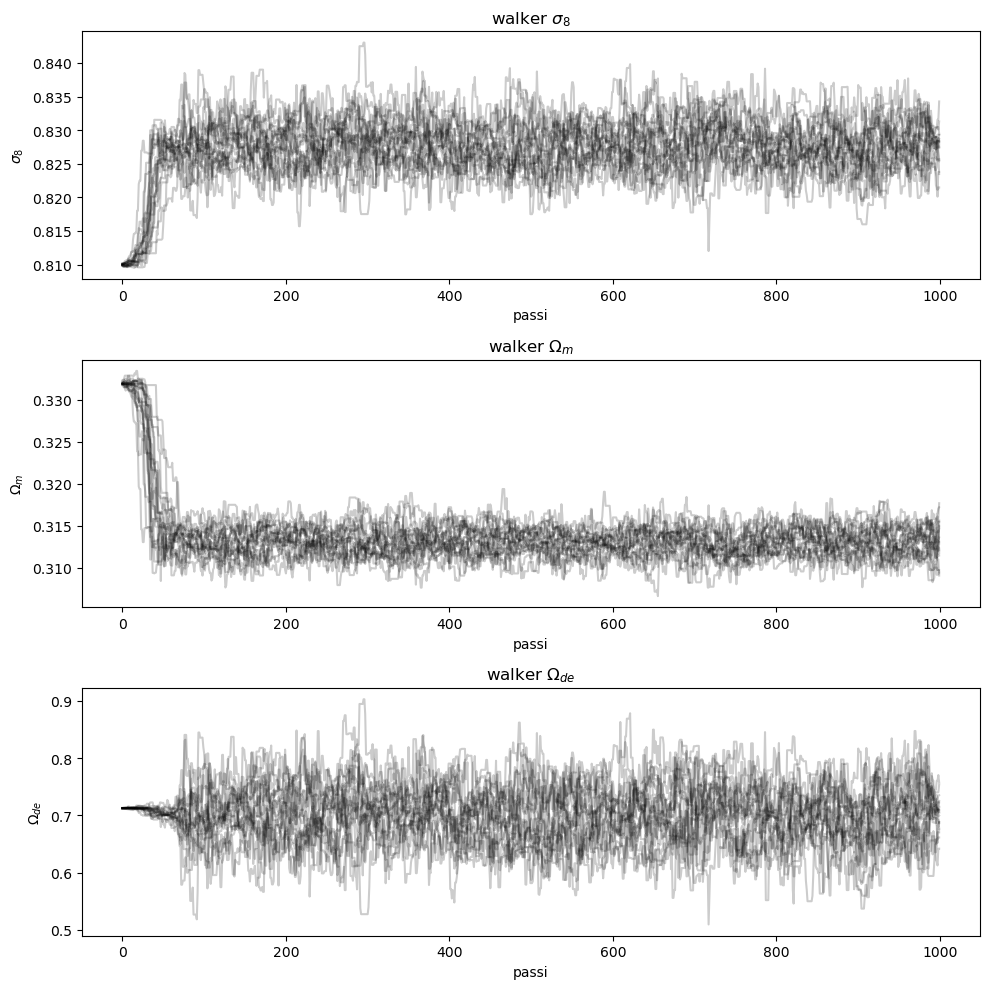

In [158]:
#======================#
##controllo fase burn-in
#======================#

##array con tutti le posizioni accettate dei 20 walkers
sample_walk1 = sampler1.get_chain() ## decommentare se si vuole fare il campionamento
#sample_walk1 = fstart3_1.reshape(-1,20,3) ## commentare se si vuole rifare il campionamento

fig = plt.figure(figsize=(10, 10))
##proiezione posizione su sigma8
ax1 = fig.add_subplot(311)
for i in range(nwalkers):
    ax1.plot(np.arange(passi),sample_walk1[:,i,0], color = 'black', alpha = 0.2)
ax1.set_title(r'walker $\sigma_{8}$')
ax1.set_xlabel('passi')
ax1.set_ylabel(r'$\sigma_{8}$')

##proiezione posizione su om0
ax2 = fig.add_subplot(312)
for i in range(nwalkers):
    ax2.plot(np.arange(passi),sample_walk1[:,i,1], color = 'black', alpha = 0.2)
ax2.set_title(r'walker $\Omega_m$')
ax2.set_xlabel('passi')
ax2.set_ylabel(r'$\Omega_m$')

ax3 = fig.add_subplot(313)
for i in range(nwalkers):
    ax3.plot(np.arange(passi),sample_walk1[:,i,2], color = 'black', alpha = 0.2)
ax3.set_title(r'walker $\Omega_{de}$')
ax3.set_xlabel('passi')
ax3.set_ylabel(r'$\Omega_{de}$')

plt.tight_layout()
plt.show()

#========================#
## fine controllo  burn-in
#========================#

In [159]:
## trovo un valore di omega_k,0 per ogni coppia om0 e ode0
Ok_samples1 = 1.0 - flat_samples1[:, 1] - flat_samples1[:, 2]
Ok_samples2 = 1.0 - flat_samples2[:, 1] - flat_samples2[:, 2]
Ok_samples3 = 1.0 - flat_samples3[:, 1] - flat_samples3[:, 2]

# dai conteggi degli istogrammi estrapolo la media e la mediana che posso utilizzare come stimatori del parametro
# e la varianza intesa come l'intervallo che contiene il 68% dei valori possibili del parametro
s8_1_mean = np.mean(flat_samples1[:, 0])
s8_1_16 = np.percentile(flat_samples1[:, 0], 16)
s8_1_median = np.percentile(flat_samples1[:, 0], 50)
s8_1_84 = np.percentile(flat_samples1[:, 0], 84)

om0_1_mean = np.mean(flat_samples1[:, 1])
om0_1_16 = np.percentile(flat_samples1[:, 1], 16)
om0_1_median = np.percentile(flat_samples1[:, 1], 50)
om0_1_84 = np.percentile(flat_samples1[:, 1], 84)

ode0_1_mean = np.mean(flat_samples1[:, 2])
ode0_1_16 = np.percentile(flat_samples1[:, 2], 16)
ode0_1_median = np.percentile(flat_samples1[:, 2], 50)
ode0_1_84 = np.percentile(flat_samples1[:, 2], 84)

Ok_1_mean = np.mean(Ok_samples1)
Ok_1_16 = np.percentile(Ok_samples1, 16)
Ok_1_median = np.percentile(Ok_samples1, 50)
Ok_1_84 = np.percentile(Ok_samples1, 84)


# Calcoli per z2
s8_2_mean = np.mean(flat_samples2[:, 0])
s8_2_16 = np.percentile(flat_samples2[:, 0], 16)
s8_2_median = np.percentile(flat_samples2[:, 0], 50)
s8_2_84 = np.percentile(flat_samples2[:, 0], 84)

om0_2_mean = np.mean(flat_samples2[:, 1])
om0_2_16 = np.percentile(flat_samples2[:, 1], 16)
om0_2_median = np.percentile(flat_samples2[:, 1], 50)
om0_2_84 = np.percentile(flat_samples2[:, 1], 84)

ode0_2_mean = np.mean(flat_samples2[:, 2])
ode0_2_16 = np.percentile(flat_samples2[:, 2], 16)
ode0_2_median = np.percentile(flat_samples2[:, 2], 50)
ode0_2_84 = np.percentile(flat_samples2[:, 2], 84)

Ok_2_mean = np.mean(Ok_samples2)
Ok_2_16 = np.percentile(Ok_samples2, 16)
Ok_2_median = np.percentile(Ok_samples2, 50)
Ok_2_84 = np.percentile(Ok_samples2, 84)


# Calcoli per z3
s8_3_mean = np.mean(flat_samples3[:, 0])
s8_3_16 = np.percentile(flat_samples3[:, 0], 16)
s8_3_median = np.percentile(flat_samples3[:, 0], 50)
s8_3_84 = np.percentile(flat_samples3[:, 0], 84)

om0_3_mean = np.mean(flat_samples3[:, 1])
om0_3_16 = np.percentile(flat_samples3[:, 1], 16)
om0_3_median = np.percentile(flat_samples3[:, 1], 50)
om0_3_84 = np.percentile(flat_samples3[:, 1], 84)

ode0_3_mean = np.mean(flat_samples3[:, 2])
ode0_3_16 = np.percentile(flat_samples3[:, 2], 16)
ode0_3_median = np.percentile(flat_samples3[:, 2], 50)
ode0_3_84 = np.percentile(flat_samples3[:, 2], 84)

Ok_3_mean = np.mean(Ok_samples3)
Ok_3_16 = np.percentile(Ok_samples3, 16)
Ok_3_median = np.percentile(Ok_samples3, 50)
Ok_3_84 = np.percentile(Ok_samples3, 84)

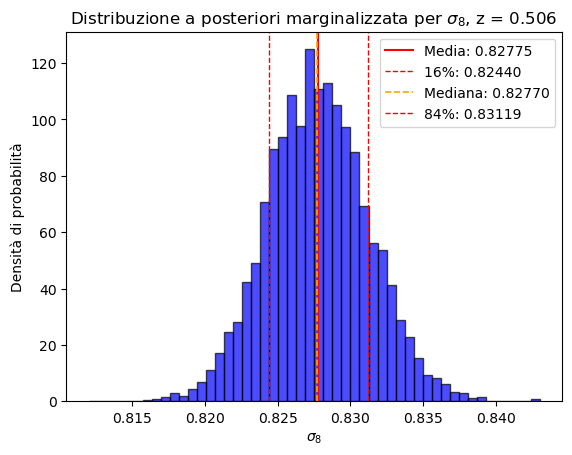

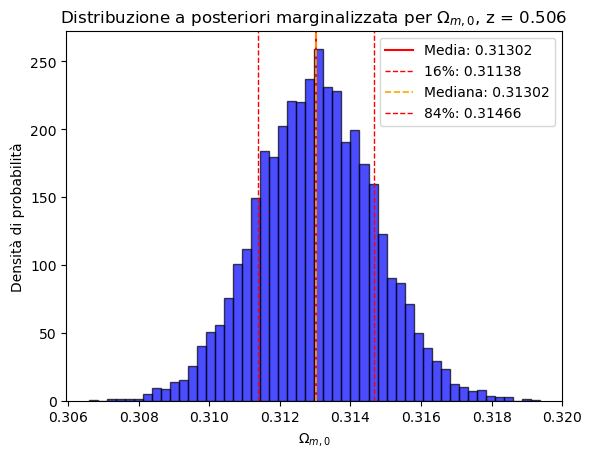

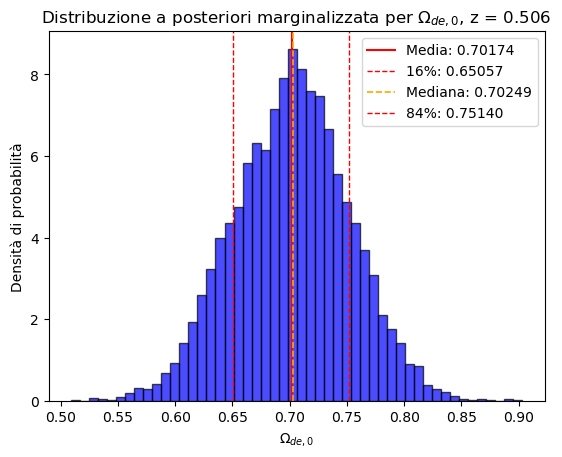

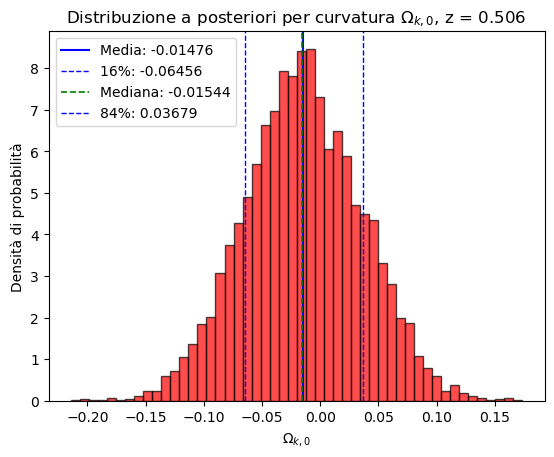

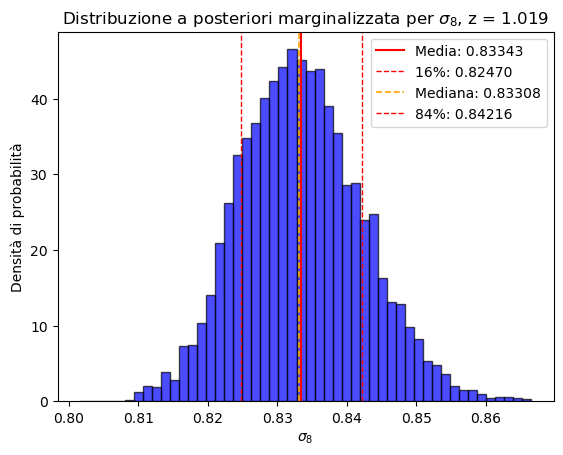

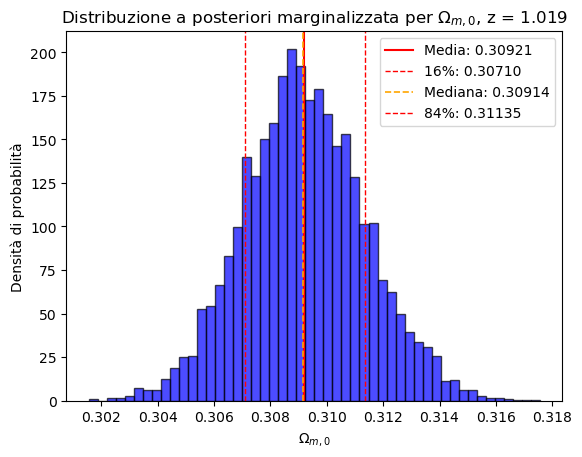

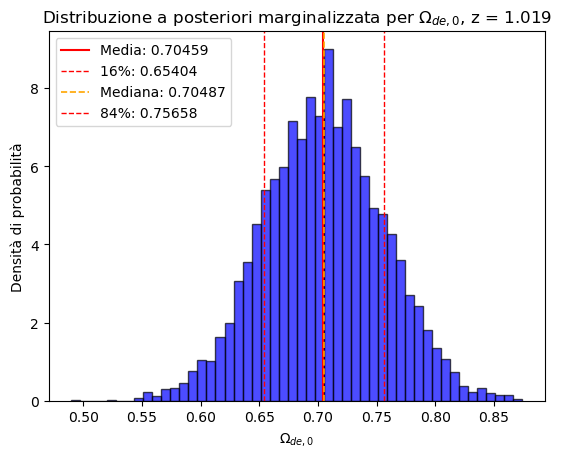

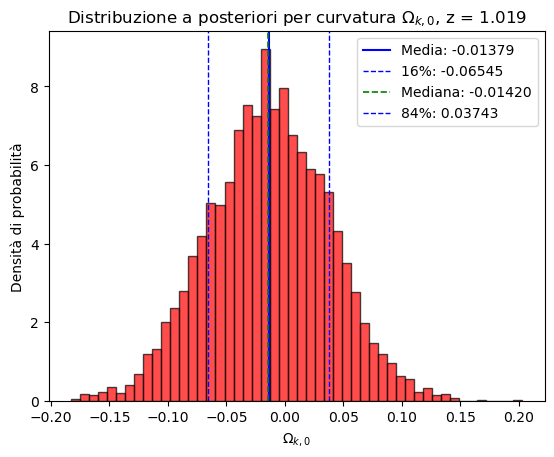

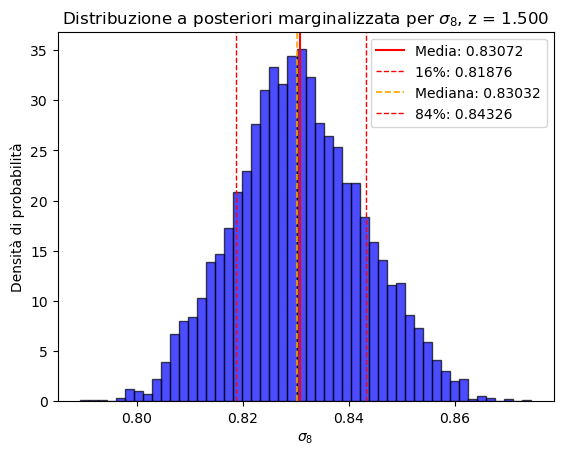

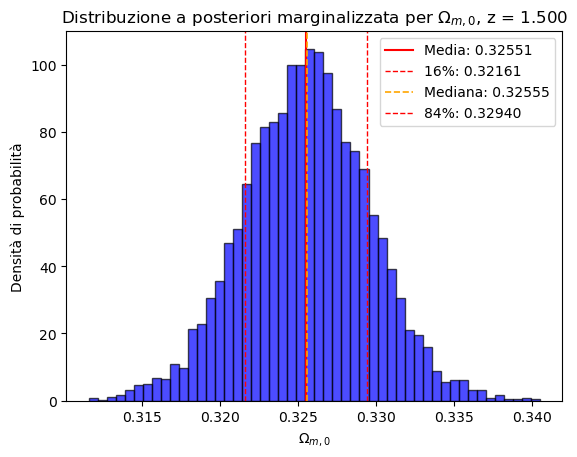

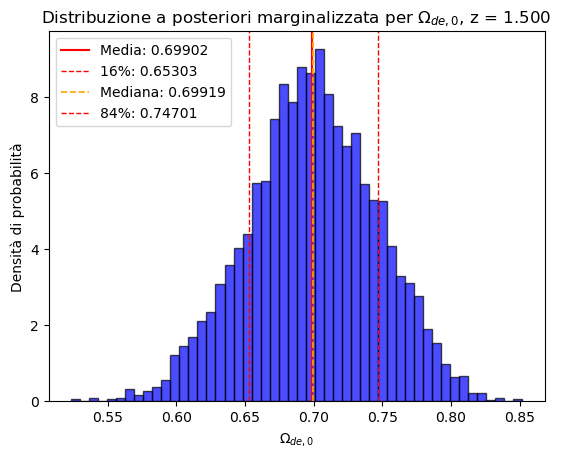

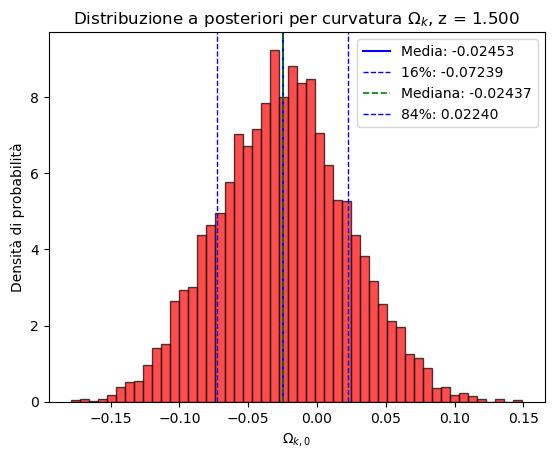

In [160]:
##marginalizzate z1
plt.figure()
plt.hist(flat_samples1[:, 0], bins=50, density=True, color='blue', alpha=0.7, edgecolor='black')
plt.axvline(s8_1_mean, color='red', linestyle='-', linewidth=1.5, label=f'Media: {s8_1_mean:.5f}')
plt.axvline(s8_1_16, color='red', linestyle='--', linewidth=1, label=f'16%: {s8_1_16:.5f}')
plt.axvline(s8_1_median, color='orange', linestyle='--', linewidth=1.2, label=f'Mediana: {s8_1_median:.5f}')
plt.axvline(s8_1_84, color='red', linestyle='--', linewidth=1, label=f'84%: {s8_1_84:.5f}')
plt.title(r'Distribuzione a posteriori marginalizzata per $\sigma_{8}$, z = 0.506 ')
plt.xlabel(r'$\sigma_{8}$')
plt.ylabel('Densità di probabilità')
plt.legend()
plt.show() 

plt.figure()
plt.hist(flat_samples1[:, 1], bins=50, density=True, color='blue', alpha=0.7, edgecolor='black')
plt.axvline(om0_1_mean, color='red', linestyle='-', linewidth=1.5, label=f'Media: {om0_1_mean:.5f}')
plt.axvline(om0_1_16, color='red', linestyle='--', linewidth=1, label=f'16%: {om0_1_16:.5f}')
plt.axvline(om0_1_median, color='orange', linestyle='--', linewidth=1.2, label=f'Mediana: {om0_1_median:.5f}')
plt.axvline(om0_1_84, color='red', linestyle='--', linewidth=1, label=f'84%: {om0_1_84:.5f}')
plt.title(r'Distribuzione a posteriori marginalizzata per $\Omega_{m,0}$, z = 0.506 ')
plt.xlabel(r'$\Omega_{m,0}$')
plt.ylabel('Densità di probabilità')
plt.legend()
plt.show() 
 

plt.figure()
plt.hist(flat_samples1[:, 2], bins=50, density=True, color='blue', alpha=0.7, edgecolor='black')
plt.axvline(ode0_1_mean, color='red', linestyle='-', linewidth=1.5, label=f'Media: {ode0_1_mean:.5f}')
plt.axvline(ode0_1_16, color='red', linestyle='--', linewidth=1, label=f'16%: {ode0_1_16:.5f}')
plt.axvline(ode0_1_median, color='orange', linestyle='--', linewidth=1.2, label=f'Mediana: {ode0_1_median:.5f}')
plt.axvline(ode0_1_84, color='red', linestyle='--', linewidth=1, label=f'84%: {ode0_1_84:.5f}')
plt.title(r'Distribuzione a posteriori marginalizzata per $\Omega_{de,0}$, z = 0.506 ')
plt.xlabel(r'$\Omega_{de,0}$')
plt.ylabel('Densità di probabilità')
plt.legend()
plt.show()


plt.figure()
plt.hist(Ok_samples1, bins=50, density=True, color='red', alpha=0.7, edgecolor='black')
plt.axvline(Ok_1_mean, color='blue', linestyle='-', linewidth=1.5, label=f'Media: {Ok_1_mean:.5f}')
plt.axvline(Ok_1_16, color='blue', linestyle='--', linewidth=1, label=f'16%: {Ok_1_16:.5f}')
plt.axvline(Ok_1_median, color='green', linestyle='--', linewidth=1.2, label=f'Mediana: {Ok_1_median:.5f}')
plt.axvline(Ok_1_84, color='blue', linestyle='--', linewidth=1, label=f'84%: {Ok_1_84:.5f}')
plt.title(r'Distribuzione a posteriori per curvatura $\Omega_{k,0}$, z = 0.506 ')
plt.xlabel(r'$\Omega_{k,0}$')
plt.ylabel('Densità di probabilità')
plt.legend()
plt.show()

##marginalizzate z2
plt.figure()
plt.hist(flat_samples2[:, 0], bins=50, density=True, color='blue', alpha=0.7, edgecolor='black')
plt.axvline(s8_2_mean, color='red', linestyle='-', linewidth=1.5, label=f'Media: {s8_2_mean:.5f}')
plt.axvline(s8_2_16, color='red', linestyle='--', linewidth=1, label=f'16%: {s8_2_16:.5f}')
plt.axvline(s8_2_median, color='orange', linestyle='--', linewidth=1.2, label=f'Mediana: {s8_2_median:.5f}')
plt.axvline(s8_2_84, color='red', linestyle='--', linewidth=1, label=f'84%: {s8_2_84:.5f}')
plt.title(r'Distribuzione a posteriori marginalizzata per $\sigma_8$, z = 1.019')
plt.xlabel(r'$\sigma_8$')
plt.ylabel('Densità di probabilità')
plt.legend()
plt.show() 

plt.figure()
plt.hist(flat_samples2[:, 1], bins=50, density=True, color='blue', alpha=0.7, edgecolor='black')
plt.axvline(om0_2_mean, color='red', linestyle='-', linewidth=1.5, label=f'Media: {om0_2_mean:.5f}')
plt.axvline(om0_2_16, color='red', linestyle='--', linewidth=1, label=f'16%: {om0_2_16:.5f}')
plt.axvline(om0_2_median, color='orange', linestyle='--', linewidth=1.2, label=f'Mediana: {om0_2_median:.5f}')
plt.axvline(om0_2_84, color='red', linestyle='--', linewidth=1, label=f'84%: {om0_2_84:.5f}')
plt.title(r'Distribuzione a posteriori marginalizzata per $\Omega_{m,0}$, z = 1.019')
plt.xlabel(r'$\Omega_{m,0}$')
plt.ylabel('Densità di probabilità')
plt.legend()
plt.show()           
    

plt.figure()
plt.hist(flat_samples2[:, 2], bins=50, density=True, color='blue', alpha=0.7, edgecolor='black')
plt.axvline(ode0_2_mean, color='red', linestyle='-', linewidth=1.5, label=f'Media: {ode0_2_mean:.5f}')
plt.axvline(ode0_2_16, color='red', linestyle='--', linewidth=1, label=f'16%: {ode0_2_16:.5f}')
plt.axvline(ode0_2_median, color='orange', linestyle='--', linewidth=1.2, label=f'Mediana: {ode0_2_median:.5f}')
plt.axvline(ode0_2_84, color='red', linestyle='--', linewidth=1, label=f'84%: {ode0_2_84:.5f}')
plt.title(r'Distribuzione a posteriori marginalizzata per $\Omega_{de,0}$, z = 1.019')
plt.xlabel(r'$\Omega_{de,0}$')
plt.ylabel('Densità di probabilità')
plt.legend()
plt.show()


plt.figure()
plt.hist(Ok_samples2, bins=50, density=True, color='red', alpha=0.7, edgecolor='black')
plt.axvline(Ok_2_mean, color='blue', linestyle='-', linewidth=1.5, label=f'Media: {Ok_2_mean:.5f}')
plt.axvline(Ok_2_16, color='blue', linestyle='--', linewidth=1, label=f'16%: {Ok_2_16:.5f}')
plt.axvline(Ok_2_median, color='green', linestyle='--', linewidth=1.2, label=f'Mediana: {Ok_2_median:.5f}')
plt.axvline(Ok_2_84, color='blue', linestyle='--', linewidth=1, label=f'84%: {Ok_2_84:.5f}')
plt.title(r'Distribuzione a posteriori per curvatura $\Omega_{k,0}$, z = 1.019')
plt.xlabel(r'$\Omega_{k,0}$')
plt.ylabel('Densità di probabilità')
plt.legend()
plt.show()
    
##marginalizzate z3
plt.figure()
plt.hist(flat_samples3[:, 0], bins=50, density=True, color='blue', alpha=0.7, edgecolor='black')
plt.axvline(s8_3_mean, color='red', linestyle='-', linewidth=1.5, label=f'Media: {s8_3_mean:.5f}')
plt.axvline(s8_3_16, color='red', linestyle='--', linewidth=1, label=f'16%: {s8_3_16:.5f}')
plt.axvline(s8_3_median, color='orange', linestyle='--', linewidth=1.2, label=f'Mediana: {s8_3_median:.5f}')
plt.axvline(s8_3_84, color='red', linestyle='--', linewidth=1, label=f'84%: {s8_3_84:.5f}')
plt.title(r'Distribuzione a posteriori marginalizzata per $\sigma_8$, z = 1.500')
plt.xlabel(r'$\sigma_8$')
plt.ylabel('Densità di probabilità')
plt.legend()
plt.show() 

plt.figure()
plt.hist(flat_samples3[:, 1], bins=50, density=True, color='blue', alpha=0.7, edgecolor='black')
plt.axvline(om0_3_mean, color='red', linestyle='-', linewidth=1.5, label=f'Media: {om0_3_mean:.5f}')
plt.axvline(om0_3_16, color='red', linestyle='--', linewidth=1, label=f'16%: {om0_3_16:.5f}')
plt.axvline(om0_3_median, color='orange', linestyle='--', linewidth=1.2, label=f'Mediana: {om0_3_median:.5f}')
plt.axvline(om0_3_84, color='red', linestyle='--', linewidth=1, label=f'84%: {om0_3_84:.5f}')
plt.title(r'Distribuzione a posteriori marginalizzata per $\Omega_{m,0}$, z = 1.500')
plt.xlabel(r'$\Omega_{m,0}$')
plt.ylabel('Densità di probabilità')
plt.legend()
plt.show()  

plt.figure()
plt.hist(flat_samples3[:, 2], bins=50, density=True, color='blue', alpha=0.7, edgecolor='black')
plt.axvline(ode0_3_mean, color='red', linestyle='-', linewidth=1.5, label=f'Media: {ode0_3_mean:.5f}')
plt.axvline(ode0_3_16, color='red', linestyle='--', linewidth=1, label=f'16%: {ode0_3_16:.5f}')
plt.axvline(ode0_3_median, color='orange', linestyle='--', linewidth=1.2, label=f'Mediana: {ode0_3_median:.5f}')
plt.axvline(ode0_3_84, color='red', linestyle='--', linewidth=1, label=f'84%: {ode0_3_84:.5f}')
plt.title(r'Distribuzione a posteriori marginalizzata per $\Omega_{de,0}$, z = 1.500')
plt.xlabel(r'$\Omega_{de,0}$')
plt.ylabel('Densità di probabilità')
plt.legend()
plt.show()

plt.figure()
plt.hist(Ok_samples3, bins=50, density=True, color='red', alpha=0.7, edgecolor='black')
plt.axvline(Ok_3_mean, color='blue', linestyle='-', linewidth=1.5, label=f'Media: {Ok_3_mean:.5f}')
plt.axvline(Ok_3_16, color='blue', linestyle='--', linewidth=1, label=f'16%: {Ok_3_16:.5f}')
plt.axvline(Ok_3_median, color='green', linestyle='--', linewidth=1.2, label=f'Mediana: {Ok_3_median:.5f}')
plt.axvline(Ok_3_84, color='blue', linestyle='--', linewidth=1, label=f'84%: {Ok_3_84:.5f}')
plt.title(r'Distribuzione a posteriori per curvatura $\Omega_k$, z = 1.500')
plt.xlabel(r'$\Omega_{k,0}$')
plt.ylabel('Densità di probabilità')
plt.legend()
plt.show()

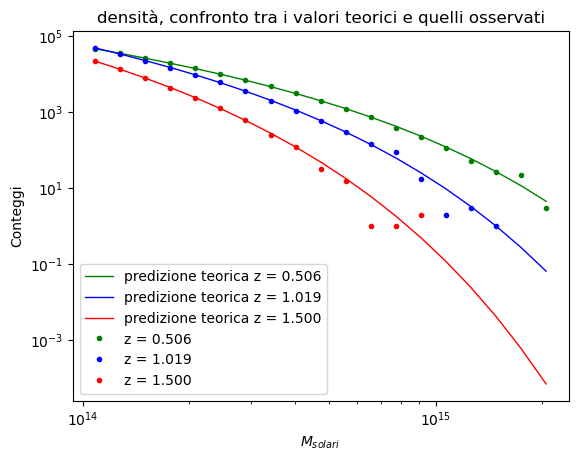

In [187]:
##confronto i valori teorici con quelli osservati

## setto i parametri dell'universo con cui calcolo n_1 teorico di z1

params = {'flat': False, 'H0': 67.77, 'Ode0': ode0_1_mean, 'Om0': om0_1_mean,
                   'Ob0': 0.049, 'sigma8': s8_1_mean, 'ns': 0.96}
cosmology.addCosmology('myCosmo', params)
cosmology.setCosmology('myCosmo')

## calcolo la HMF nei centri di ogni bin di massa con i nuovi parametri
HMF1_teor = mass_function.massFunction(cntr, z1.z.iloc[0], mdef='vir', model='despali16', q_out='dndlnM')

## converto in conteggi
n1_teor = HMF1_teor * (V1 * dlog_M)

## setto i parametri dell'universo con cui calcolo n_2 teorico di z2

params = {'flat': False, 'H0': 67.77, 'Ode0': ode0_2_mean, 'Om0': om0_2_mean,
                   'Ob0': 0.049, 'sigma8': s8_2_mean, 'ns': 0.96}
cosmology.addCosmology('myCosmo', params)
cosmology.setCosmology('myCosmo')

## calcolo la HMF nei centri di ogni bin di massa con i nuovi parametri
HMF2_teor = mass_function.massFunction(cntr, z2.z.iloc[0], mdef='vir', model='despali16', q_out='dndlnM')

## converto in conteggi
n2_teor = HMF2_teor * (V2 * dlog_M)

## setto i parametri dell'universo con cui calcolo n_3 teorico di z3

params = {'flat': False, 'H0': 67.77, 'Ode0': ode0_3_mean, 'Om0': om0_3_mean,
                   'Ob0': 0.049, 'sigma8': s8_3_mean, 'ns': 0.96}
cosmology.addCosmology('myCosmo', params)
cosmology.setCosmology('myCosmo')

## calcolo la HMF nei centri di ogni bin di massa con i nuovi parametri
HMF3_teor = mass_function.massFunction(cntr, z3.z.iloc[0], mdef='vir', model='despali16', q_out='dndlnM')

## converto in conteggi
n3_teor = HMF3_teor * (V3 * dlog_M)

## plotto i grafici del confronto
plt.figure()
plt.plot(cntr, n1_teor, label = 'predizione teorica z = 0.506', color = 'green', linewidth = 1)
plt.plot(cntr, n2_teor, label = 'predizione teorica z = 1.019', color = 'blue', linewidth = 1)
plt.plot(cntr, n3_teor, label = 'predizione teorica z = 1.500', color = 'red', linewidth = 1)
plt.plot(cntr, n1, color = 'green', markersize = 3, marker='o', linestyle='none', label = 'z = 0.506')
plt.plot(cntr, n2, color = 'blue', markersize = 3, marker='o', linestyle='none', label = 'z = 1.019')
plt.plot(cntr, n3, color = 'red', markersize = 3, marker='o', linestyle='none', label = 'z = 1.500')
plt.title('densità, confronto tra i valori teorici e quelli osservati')
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$M_{solari}$')
plt.ylabel('Conteggi')
plt.legend()
plt.show()

In [188]:
## chi quadro per ogni bin di redshift
chi_quad1 = np.sum(((n1-n1_teor)**2) / n1_teor) / (bin_1 - 3)
chi_quad2 = np.sum(((n2-n2_teor)**2) / n2_teor) / (bin_2 - 3)
chi_quad3 = np.sum(((n3-n3_teor)**2) / n3_teor) / (bin_3 - 3)
chi_quad_tot = (np.sum(((n1-n1_teor)**2)/n1_teor) + np.sum(((n2-n2_teor)**2)/n2_teor) + np.sum(((n3-n3_teor)**2)/n3_teor)) / (bin_1 + bin_2 + bin_3 - 9)

print(f'z = 0.506, Chi_quadro = {chi_quad1:.3f}')
print(f'z = 1.019, Chi_quadro = {chi_quad2:.3f}')                   
print(f'z = 1.500, Chi_quadro = {chi_quad3:.3f}') 
print(f'modello totale, chi_quadro = {chi_quad_tot:.3f}') 

z = 0.506, Chi_quadro = 1.689
z = 1.019, Chi_quadro = 2.837
z = 1.500, Chi_quadro = 2.664
modello totale, chi_quadro = 2.343


In [163]:
print(f" I valori della media dei campioni di Omega_k nei tre casi:\nz = 0.506 :{Ok_1_mean:.4f} \nz = 1.019 :{Ok_2_mean:.4f} \nz = 1.500 :{Ok_3_mean:.4f}")

 I valori della media dei campioni di Omega_k nei tre casi:
z = 0.506 :-0.0148 
z = 1.019 :-0.0138 
z = 1.500 :-0.0245


è interessante anche vedere che se viene usato come stimatore di $\Omega_{k,0}$ la media del campione relativo allo stesso emerge che nei tre casi il valore medio di $\Omega_{k,0}$ è minore di zero, il che implicherebbe (se la media coincidesse con il valore vero) che l'universo non sia piatto ma curvo e chiuso. Chiaramente dai grafici si vede che nell'intervallo contenente il 68% dei valori più probabili sono compresi anche valori di $\Omega_{k,0}$ positivi.

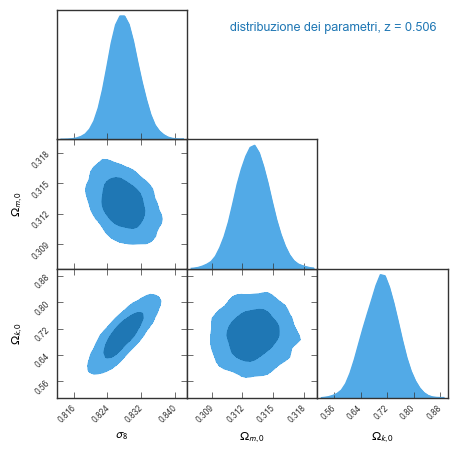

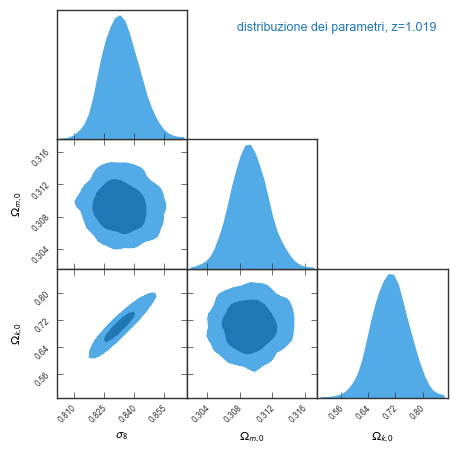

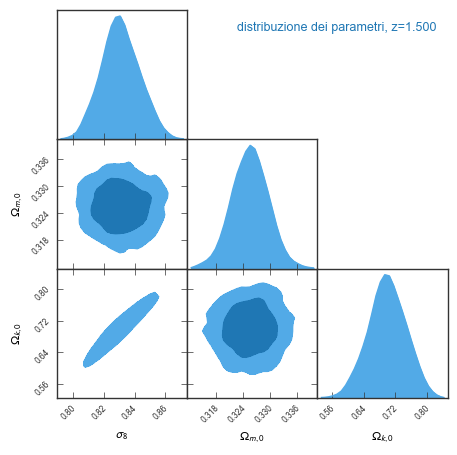

In [164]:
## z1
GTC = pygtc.plotGTC(chains=flat_samples1,
                    paramNames=[r'$\sigma_{8}$', '$\Omega_{m,0}$', '$\Omega_{k,0}$'],
                    chainLabels=['distribuzione dei parametri, z = 0.506'],
                    figureSize='MNRAS_page')

## z2
GTC = pygtc.plotGTC(chains=flat_samples2,
                    paramNames=[r'$\sigma_{8}$', '$\Omega_{m,0}$', '$\Omega_{k,0}$'],
                    chainLabels=['distribuzione dei parametri, z=1.019'],
                    figureSize='MNRAS_page')

## z3
GTC = pygtc.plotGTC(chains=flat_samples3,
                    paramNames=[r'$\sigma_{8}$', '$\Omega_{m,0}$', '$\Omega_{k,0}$'],
                    chainLabels=['distribuzione dei parametri, z=1.500'],
                    figureSize='MNRAS_page')

Si vede quindi come l'anticorrelazione presente tra $\sigma_{8}$ e $\Omega_{m,0}$ sia quasi del tutto sparita nel modello in 3 dimensioni, mentre emerge la forte correlazione tra $\sigma_{8}$ e $\Omega_{k,0}$

Viene infine presentata la stessa analisi ma utilizzando come campione l'insieme delle osservazioni nei tre bin di redshift (come è stato fatto nel caso in cui è stato ipotizzato l'universo piatto)

In [165]:
## setto i parametri del mio universo
params = {'flat': False, 'H0': 67.77, 'Ode0': 0.69, 'Om0': 0.31, 'Ob0': 0.049, 'sigma8': 0.81, 'ns': 0.96}
cosmology.addCosmology('myCosmo', params)
cosmology.setCosmology('myCosmo')

def log_prior3(theta):
    s8, om, ode0 = theta
    if 0.01 <= om <= 1.1 and 0.1 <= s8 <= 1.1 and 0.01 <= ode0 <= 1.5: 
        return -0.5 * ((ode0 - 0.7) / 0.05)**2
    return -np.inf


def log_likelyhood_tot3(theta):
    s8, om, ode0 = theta
    params = {'flat': False, 'H0': 67.77, 'Ode0': ode0, 'Om0': om, 'Ob0': 0.048254,
    'sigma8': s8, 'ns': 0.96}
    cosmology.addCosmology('myCosmo', params)
    cosmology.setCosmology('myCosmo')
    
    ##trovo la densità teorica di conteggi e la converto nel numero di conteggi
    dens_teor1 = mass_function.massFunction(cntr, z1.z.iloc[0], mdef='vir', model='despali16', q_out='dndlnM')
    n_teor1 = dens_teor1 * z1.vol.iloc[0] * dlog_M
    
    dens_teor2 = mass_function.massFunction(cntr, z2.z.iloc[0], mdef='vir', model='despali16', q_out='dndlnM')
    n_teor2 = dens_teor2 * z2.vol.iloc[0] * dlog_M
    
    dens_teor3 = mass_function.massFunction(cntr, z3.z.iloc[0], mdef='vir', model='despali16', q_out='dndlnM')
    n_teor3 = dens_teor3 * z3.vol.iloc[0] * dlog_M
    
    ##limite per evitare di avere -inf
    n_teor1 = np.maximum(n_teor1, 1e-10)
    n_teor2 = np.maximum(n_teor2, 1e-10)
    n_teor3 = np.maximum(n_teor3, 1e-10)
    
    ##scrivo la funzione loglikelyhood (escludendo il termine che non dipende dai parametri)
    ll1 = np.sum(n1 * np.log(n_teor1) - n_teor1)
    ll2 = np.sum(n2 * np.log(n_teor2) - n_teor2)
    ll3 = np.sum(n3 * np.log(n_teor3) - n_teor3)
    return ll1 + ll2 + ll3
    

def log_posterior_tot3(theta):
    if not np.isfinite(log_prior3(theta)):
        return -np.inf
    return log_prior3(theta) + log_likelyhood_tot3(theta)
   
##inizio la parte di inferenza vera e propria
import emcee
from scipy.optimize import minimize
rng = np.random.default_rng()

##trovo il massimo della funzione per far partire i walkers da li

##funzione da minimizzare
def nll_tot3(theta):
    return -log_posterior_tot3(theta)

limiti = ((0.1, 1.1), (0.01, 1.1), (0.01, 1.5))
start = np.array([0.81, 0.31, 0.69]) 


max_ll_tot = minimize(nll_tot3, start, bounds=limiti)
start_pos_tot = max_ll_tot.x  

##parametri emcee
nwalkers = 20
ndim = 3
passi = 1000

##posizione di partenza degli walkers
pos_walk_tot = start_pos_tot + 1e-4 * rng.normal(size=(nwalkers, ndim))


sampler_tot = emcee.EnsembleSampler(nwalkers, ndim, log_posterior_tot3)
sampler_tot.run_mcmc(pos_walk_tot, passi, progress=True); 

##estrapolazione del singolo campione congiunto        
samples_tot = sampler_tot.get_chain()[150:,:,:]
flat_samples_tot = samples_tot.reshape(-1,3)

100%|██████████| 1000/1000 [59:36<00:00,  3.58s/it]


In [166]:
##salvo np.array i samples già ottenuti in locale
#fstart_tot = np.loadtxt("3parametri_tot.csv", delimiter=",", skiprows=1)
#flat_samples_tot = fstart_tot[20*150:,]

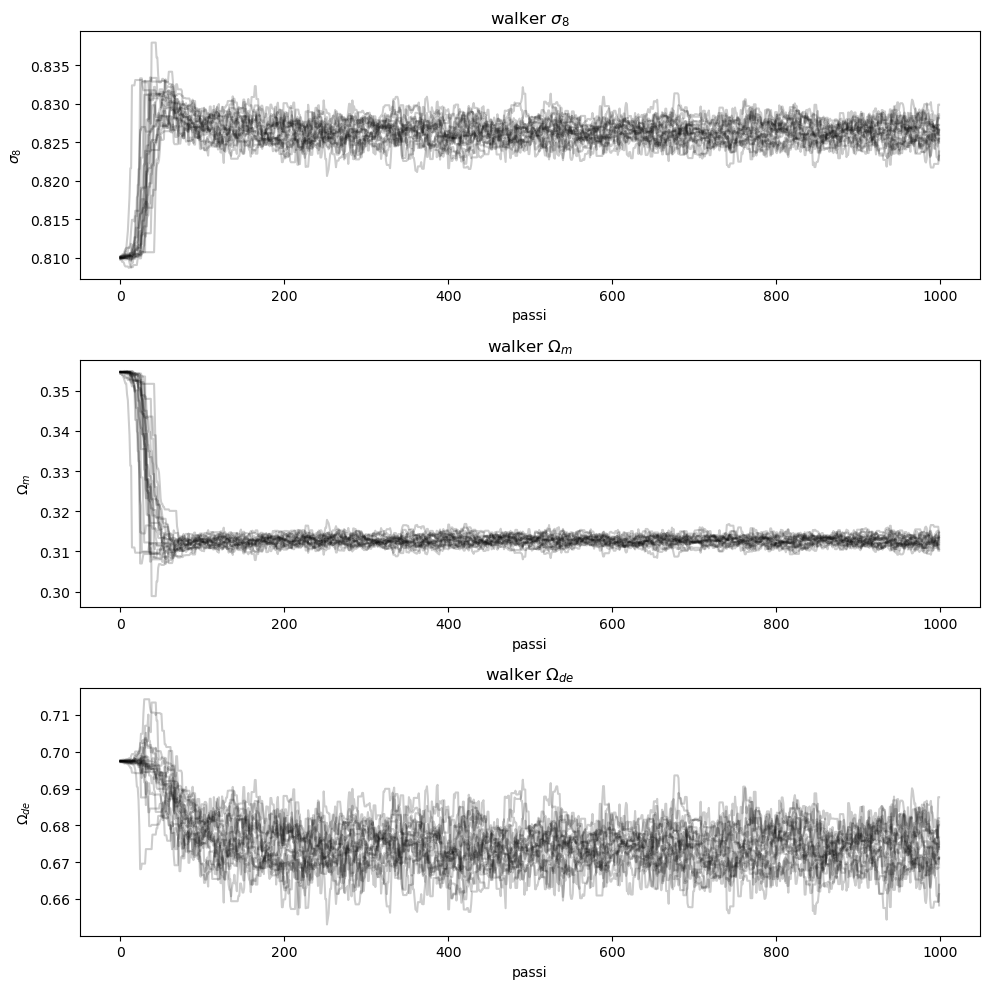

In [167]:
#======================#
##controllo fase burn-in
#======================#

## array con tutte le posizioni accettate degli walkers
sample_walk_tot = sampler_tot.get_chain() ## decommentare se si vuole fare il campionamento
#sample_walk_tot = fstart_tot.reshape(-1,20,3) ## commentare se si vuole rifare il campionamento


fig = plt.figure(figsize=(10, 10))

##proiezione posizione su sigma8
ax1 = fig.add_subplot(311)
for i in range(nwalkers):
    ax1.plot(np.arange(passi),sample_walk_tot[:,i,0], color = 'black', alpha = 0.2)
ax1.set_title(r'walker $\sigma_{8}$')
ax1.set_xlabel('passi')
ax1.set_ylabel(r'$\sigma_{8}$')

##proiezione posizione su om0
ax2 = fig.add_subplot(312)
for i in range(nwalkers):
    ax2.plot(np.arange(passi),sample_walk_tot[:,i,1], color = 'black', alpha = 0.2)
ax2.set_title(r'walker $\Omega_m$')
ax2.set_xlabel('passi')
ax2.set_ylabel(r'$\Omega_m$')

ax3 = fig.add_subplot(313)
for i in range(nwalkers):
    ax3.plot(np.arange(passi),sample_walk_tot[:,i,2], color = 'black', alpha = 0.2)
ax3.set_title(r'walker $\Omega_{de}$')
ax3.set_xlabel('passi')
ax3.set_ylabel(r'$\Omega_{de}$')

plt.tight_layout()
plt.show()

#========================#
## fine controllo  burn-in
#========================#

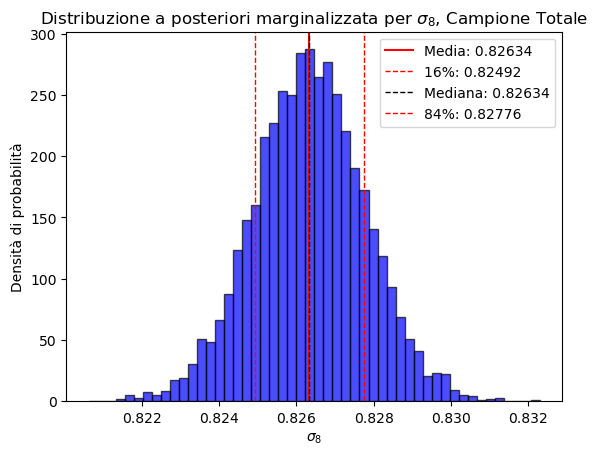

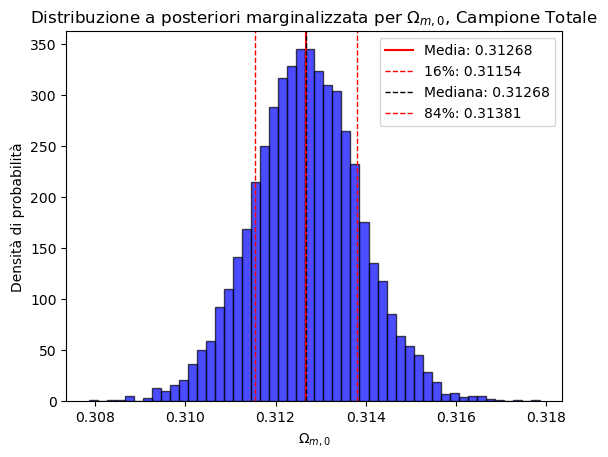

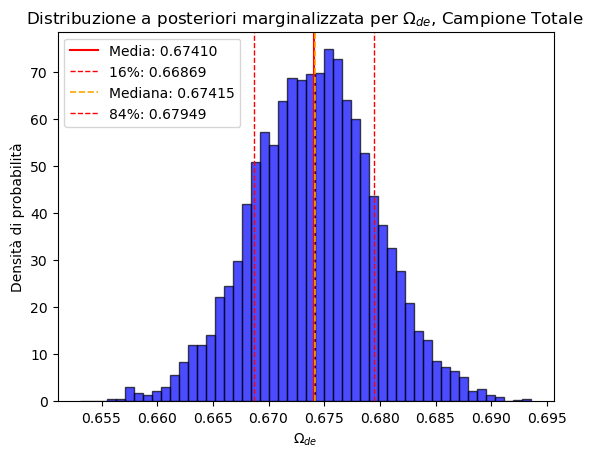

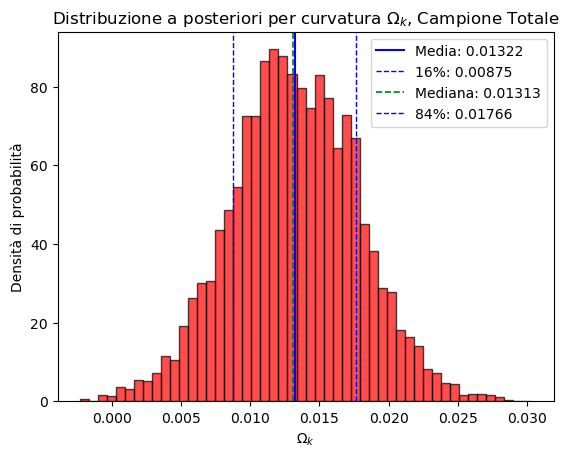

In [168]:
Ok_samples_tot = 1.0 - flat_samples_tot[:, 1] - flat_samples_tot[:, 2]
# dai conteggi degli istogrammi estrapolo la media e la mediana che posso utilizzare come stimatori del parametro
# e la varianza intesa come l'intervallo che contiene il 68% dei valori possibili del parametro

s8_tot_mean = np.mean(flat_samples_tot[:, 0])
s8_tot_16 = np.percentile(flat_samples_tot[:, 0], 16)
s8_tot_median = np.percentile(flat_samples_tot[:, 0], 50)
s8_tot_84 = np.percentile(flat_samples_tot[:, 0], 84)

om0_tot_mean = np.mean(flat_samples_tot[:, 1])
om0_tot_16 = np.percentile(flat_samples_tot[:, 1], 16)
om0_tot_median = np.percentile(flat_samples_tot[:, 1], 50)
om0_tot_84 = np.percentile(flat_samples_tot[:, 1], 84)

ode0_tot_mean = np.mean(flat_samples_tot[:, 2])
ode0_tot_16 = np.percentile(flat_samples_tot[:, 2], 16)
ode0_tot_median = np.percentile(flat_samples_tot[:, 2], 50)
ode0_tot_84 = np.percentile(flat_samples_tot[:, 2], 84)

Ok_tot_mean = np.mean(Ok_samples_tot)
Ok_tot_16 = np.percentile(Ok_samples_tot, 16)
Ok_tot_median = np.percentile(Ok_samples_tot, 50)
Ok_tot_84 = np.percentile(Ok_samples_tot, 84)


##marginalizzate
plt.figure()
plt.hist(flat_samples_tot[:, 0], bins=50, density=True, color='blue', alpha=0.7, edgecolor='black')
plt.axvline(s8_tot_mean, color='red', linestyle='-', linewidth=1.5, label=f'Media: {s8_tot_mean:.5f}')
plt.axvline(s8_tot_16, color='red', linestyle='--', linewidth=1, label=f'16%: {s8_tot_16:.5f}')
plt.axvline(s8_tot_median, color='black', linestyle='--', linewidth=1, label=f'Mediana: {s8_tot_median:.5f}')
plt.axvline(s8_tot_84, color='red', linestyle='--', linewidth=1, label=f'84%: {s8_tot_84:.5f}')
plt.title(r'Distribuzione a posteriori marginalizzata per $\sigma_{8}$, Campione Totale')
plt.xlabel(r'$\sigma_{8}$')
plt.ylabel('Densità di probabilità')
plt.legend()
plt.show() 

plt.figure()
plt.hist(flat_samples_tot[:, 1], bins=50, density=True, color='blue', alpha=0.7, edgecolor='black')
plt.axvline(om0_tot_mean, color='red', linestyle='-', linewidth=1.5, label=f'Media: {om0_tot_mean:.5f}')
plt.axvline(om0_tot_16, color='red', linestyle='--', linewidth=1, label=f'16%: {om0_tot_16:.5f}')
plt.axvline(om0_tot_median, color='black', linestyle='--', linewidth=1, label=f'Mediana: {om0_tot_median:.5f}')
plt.axvline(om0_tot_84, color='red', linestyle='--', linewidth=1, label=f'84%: {om0_tot_84:.5f}')
plt.title(r'Distribuzione a posteriori marginalizzata per $\Omega_{m,0}$, Campione Totale')
plt.xlabel(r'$\Omega_{m,0}$')
plt.ylabel('Densità di probabilità')
plt.legend()
plt.show()  

plt.figure()
plt.hist(flat_samples_tot[:, 2], bins=50, density=True, color='blue', alpha=0.7, edgecolor='black')
plt.axvline(ode0_tot_mean, color='red', linestyle='-', linewidth=1.5, label=f'Media: {ode0_tot_mean:.5f}')
plt.axvline(ode0_tot_16, color='red', linestyle='--', linewidth=1, label=f'16%: {ode0_tot_16:.5f}')
plt.axvline(ode0_tot_median, color='orange', linestyle='--', linewidth=1.2, label=f'Mediana: {ode0_tot_median:.5f}')
plt.axvline(ode0_tot_84, color='red', linestyle='--', linewidth=1, label=f'84%: {ode0_tot_84:.5f}')
plt.title(r'Distribuzione a posteriori marginalizzata per $\Omega_{de}$, Campione Totale ')
plt.xlabel(r'$\Omega_{de}$')
plt.ylabel('Densità di probabilità')
plt.legend()
plt.show()


plt.figure()
plt.hist(Ok_samples_tot, bins=50, density=True, color='red', alpha=0.7, edgecolor='black')
plt.axvline(Ok_tot_mean, color='blue', linestyle='-', linewidth=1.5, label=f'Media: {Ok_tot_mean:.5f}')
plt.axvline(Ok_tot_16, color='blue', linestyle='--', linewidth=1, label=f'16%: {Ok_tot_16:.5f}')
plt.axvline(Ok_tot_median, color='green', linestyle='--', linewidth=1.2, label=f'Mediana: {Ok_tot_median:.5f}')
plt.axvline(Ok_tot_84, color='blue', linestyle='--', linewidth=1, label=f'84%: {Ok_tot_84:.5f}')
plt.title(r'Distribuzione a posteriori per curvatura $\Omega_k$, Campione Totale')
plt.xlabel(r'$\Omega_k$')
plt.ylabel('Densità di probabilità')
plt.legend()
plt.show()

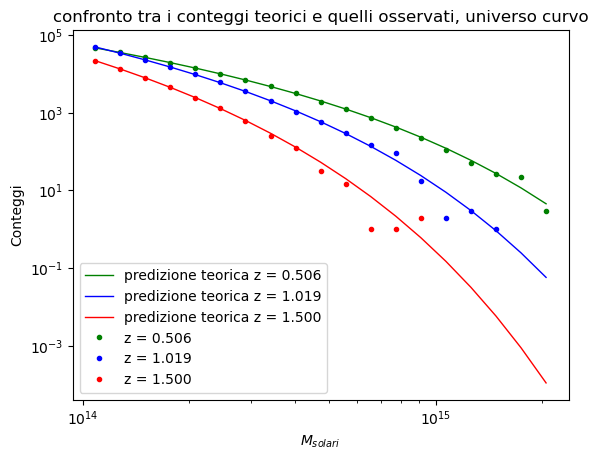

In [183]:
##confronto i valori teorici con quelli osservati

## setto i parametri dell'universo con quelli stimati

params = {'flat': False, 'H0': 67.77, 'Ode0': ode0_tot_mean, 'Om0': om0_tot_mean,
                   'Ob0': 0.049, 'sigma8': s8_tot_mean, 'ns': 0.96}
cosmology.addCosmology('myCosmo', params)
cosmology.setCosmology('myCosmo')

## calcolo la HMF nei centri di ogni bin di massa con i nuovi parametri
HMF1_teor = mass_function.massFunction(cntr, z1.z.iloc[0], mdef='vir', model='despali16', q_out='dndlnM')

## converto in conteggi
n1_teor = HMF1_teor * (V1 * dlog_M)

## calcolo la HMF nei centri di ogni bin di massa con i nuovi parametri
HMF2_teor = mass_function.massFunction(cntr, z2.z.iloc[0], mdef='vir', model='despali16', q_out='dndlnM')

## converto in conteggi
n2_teor = HMF2_teor * (V2 * dlog_M)

## calcolo la HMF nei centri di ogni bin di massa con i nuovi parametri
HMF3_teor = mass_function.massFunction(cntr, z3.z.iloc[0], mdef='vir', model='despali16', q_out='dndlnM')

## converto in conteggi
n3_teor = HMF3_teor * (V3 * dlog_M)

## plotto i grafici del confronto
plt.figure()
plt.plot(cntr, n1_teor, label = 'predizione teorica z = 0.506', color = 'green', linewidth = 1)
plt.plot(cntr, n2_teor, label = 'predizione teorica z = 1.019', color = 'blue', linewidth = 1)
plt.plot(cntr, n3_teor, label = 'predizione teorica z = 1.500', color = 'red', linewidth = 1)
plt.plot(cntr, n1, color = 'green', markersize = 3, marker='o', linestyle='none', label = 'z = 0.506')
plt.plot(cntr, n2, color = 'blue', markersize = 3, marker='o', linestyle='none', label = 'z = 1.019')
plt.plot(cntr, n3, color = 'red', markersize = 3, marker='o', linestyle='none', label = 'z = 1.500')
plt.title('confronto tra i conteggi teorici e quelli osservati, universo curvo')
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$M_{solari}$')
plt.ylabel('Conteggi')
plt.legend()
plt.show()

In [184]:
## chi quadro per ogni bin di redshift
chi_quad_tot = (np.sum(((n1-n1_teor)**2)/n1_teor) + np.sum(((n2-n2_teor)**2)/n2_teor) + np.sum(((n3-n3_teor)**2)/n3_teor)) / (bin_1 + bin_2 + bin_3 - 3)
 
print(f'modello totale, chi_quadro = {chi_quad_tot:.3f}') 

modello totale, chi_quadro = 2.296


In [185]:
print(f" il valore della media del campione di Omega_k: {Ok_tot_mean:.4f}")

 il valore della media del campione di Omega_k: 0.0132


anche in questo caso il valore di $\Omega_{k,0}$ è , questo implica ancora una volta un universo curvo

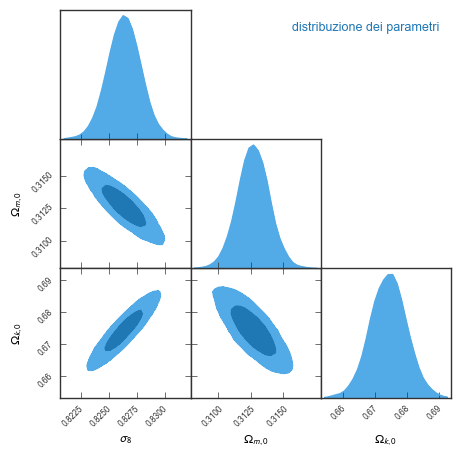

In [186]:
GTC = pygtc.plotGTC(chains=flat_samples_tot,
                    paramNames=[r'$\sigma_{8}$', '$\Omega_{m,0}$', '$\Omega_{k,0}$'],
                    chainLabels=['distribuzione dei parametri'],
                    figureSize='MNRAS_page')

Quindi complessivamente emerge come facendo inferenza sui parametri, utilizando il modello curvo dell'universo, il valore di $\chi^{2}$ ridotto diminuisca il che indica che questo sia il modello migliore; invece per quanto riguarda la distribuzione di $\Omega_{k,0}$, si deduce che questa non sia perfettamente simmetrica rispetto allo zero ma che tenda verso i valori negativi.